# **Credit Risk Analysis on Home Equity Data**
Notebook ini dibuat untuk memenuhi UAS Mata Kuliah Machine Learning (DSB07)

---

**Anggota Kelompok:**
1. 32230032 - Charles Hartanto
2. 32230036 - Wendy Tjung
3. 32230039 - Justin Wijaya

---

Studi kasus ini menggunakan dataset `ajay1735/hmeq-data` dari kaggle yang mengandung informasi tentang performa kredit dari 5.960 pinjaman ekuitas rumah (home equity loans) yaitu pinjaman yang jaminannya adalah persentase kepemilikan rumah yang telah dibayarkan selama periode cicilan berlangsung. Dataset ini bersifat organik yang didapatkan dari departemen kredit konsumen sebuah lembaga perbankan di Amerika Serikat (karena format datanya simetris dengan Equal Credit Opportunity Act) dan pertama kali dipopulerkan penggunaan secara publik oleh **SAS Institute** (awalnya untuk benchmark data mining dan machine learning milik mereka sendiri).

---

### **Penting: Connect notebook ini ke *runtime dengan GPU* untuk performa eksekusi yang jauh lebih baik!***
Hal ini berlaku baik untuk sekadar inferensi saja, testing model dengan dataset test, apalagi retrain model secara menyeluruh.

**Langkah-Langkah *Set Runtime ke GPU Accelerator*:**
1. Klik dropdown di kanan atas (di sebelah kanan RAM & Disk kalau sudah ter-*connect* dengan runtime CPU atau lainnya).
2. Pilih **Change Runtime Type**.
3. Di **Hardware Accelerator**, pilih **T4 GPU**.
4. Klik **Save** di kanan bawah dialog.

*) khususnya di bagian yang menggunakan neural network (ANN) sekalipun hanya inferensi

## **Download Dataset**

Run cell di bawah ini hanya jika ingin menggunakan dataset berkualitas dalam pelatihan model dan pengujian model dikarenakan **dataset yang tekandung di dalamnya sudah memiliki ground truth berupa label yang dianotasikan secara manual oleh ahli terkait**.

In [ ]:
import os
import pandas as pd
from pathlib import Path
import kagglehub

try:
  download_dir = kagglehub.dataset_download("ajay1735/hmeq-data")
  csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]

  if not csv_files:
      raise FileNotFoundError("Format .csv tidak ditemukan di folder unduhan KaggleHub.")

  csv_path = Path(download_dir) / csv_files[0]

except Exception as e:
  raise FileNotFoundError(
      "Dataset gagal dimuat. Sediakan file 'hmeq.csv' di direktori aktif "
      "atau pastikan runtime mendukung library kagglehub."
  ) from e

# 3. Baca dataset ke DataFrame untuk keperluan preview
df = pd.read_csv(csv_path)

# 4. Tampilkan metadata ringkas dan struktur data
print(f"Source Path  : {csv_path}")
print(f"Total Baris  : {df.shape[0]:,}")
print(f"Total Kolom  : {df.shape[1]}")
print("-" * 65)
print("Preview Data:")
display(df.head())

100%|██████████| 145k/145k [00:00<00:00, 32.4MB/s]

Extracting files...
Source Path  : /root/.cache/kagglehub/datasets/ajay1735/hmeq-data/versions/1/hmeq.csv
Total Baris  : 5,960
Total Kolom  : 13
-----------------------------------------------------------------
Preview Data:


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


## **Explanatory Data Analysis (EDA)**

Run cell di bawah ini untuk melakukan investigasi menyeluruh terhadap dataset HMEQ:
1. Bedah struktur tipe data.
2. Statistik deskriptif.
3. Ketidakseimbangan kelas berdasarkan label di kolom BAD.
4. Pemetaan komprehensif terhadap missing value.
1. Pola sebaran data diurai secara univariat lewat histogram dinamis (bar chart).
2. Eksplorasi hubungan perilaku finansial terhadap risiko gagal bayar dengan violin plot.
3. Deteksi multikolinearitas melalui heatmap korelasi Spearman.

Insight visual dan struktural yang didapatkan dari fase ini diharapkan dapat menjadi kompas heuristik yang solid dalam menentukan keputusan preprocessing serta cherry-picking fitur agar performa klustering risiko dan klasifikasinya meningkat.


1. Tipe Data Tiap Fitur


,Tipe Data
BAD,int64
LOAN,int64
MORTDUE,float64
VALUE,float64
REASON,object
JOB,object
YOJ,float64
DEROG,float64
DELINQ,float64
CLAGE,float64



2. Statistik Deskriptif Fitur Numerik


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.0,5960.00,5442.00,5848.00,5445.00,5252.00,5380.00,5652.00,5450.00,5738.00,4693.00
mean,0.2,18607.97,73760.82,101776.05,8.92,0.25,0.45,179.77,1.19,21.30,33.78
std,0.4,11207.48,44457.61,57385.78,7.57,0.85,1.13,85.81,1.73,10.14,8.60
min,0.0,1100.00,2063.00,8000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.52
25%,0.0,11100.00,46276.00,66075.50,3.00,0.00,0.00,115.12,0.00,15.00,29.14
50%,0.0,16300.00,65019.00,89235.50,7.00,0.00,0.00,173.47,1.00,20.00,34.82
75%,0.0,23300.00,91488.00,119824.25,13.00,0.00,0.00,231.56,2.00,26.00,39.00
max,1.0,89900.00,399550.00,855909.00,41.00,10.00,15.00,1168.23,17.00,71.00,203.31



3. Statistik Deskriptif Fitur Kategorikal


,REASON,JOB
count,5708,5681
unique,2,6
top,DebtCon,Other
freq,3928,2388



4. Distribusi Target BAD


,Jumlah,Persentase (%)
BAD=0 (Lunas),4771,80.05
BAD=1 (Default),1189,19.95



5. Peta Missing Value Awal


,Missing,Persentase (%)
DEBTINC,1267,21.26
DEROG,708,11.88
DELINQ,580,9.73
MORTDUE,518,8.69
YOJ,515,8.64
NINQ,510,8.56
CLAGE,308,5.17
JOB,279,4.68
REASON,252,4.23
CLNO,222,3.72


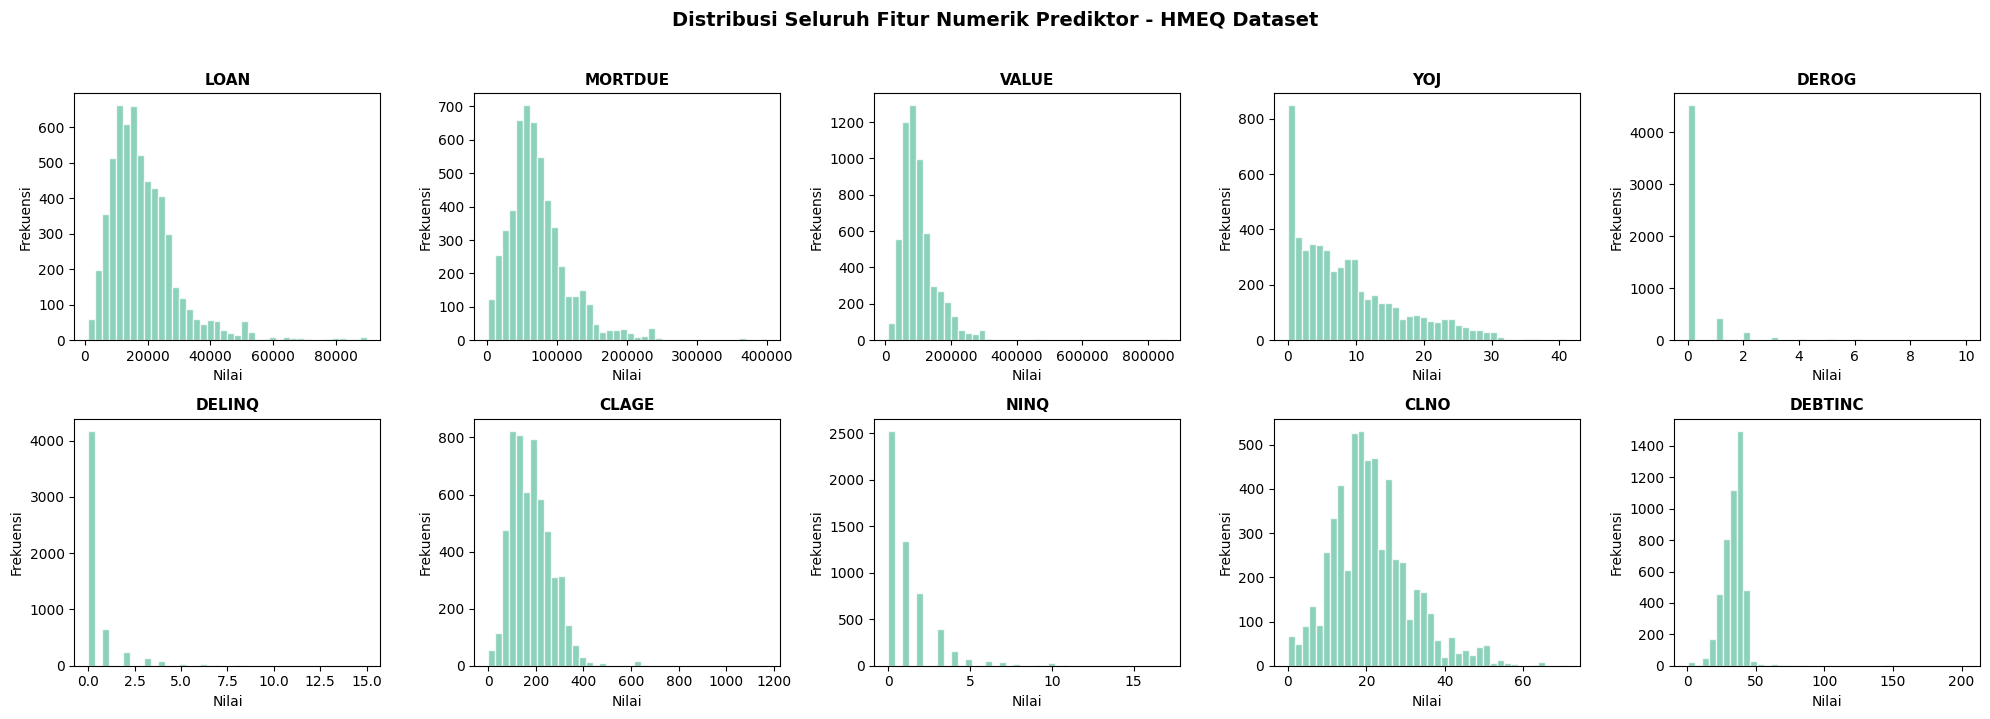


6. Visualisasi Distribusi Fitur Kategorikal


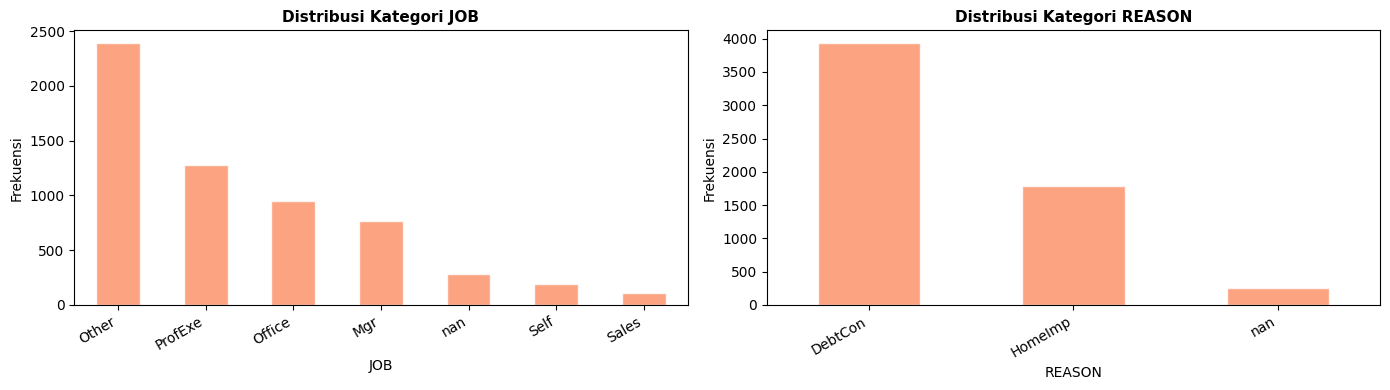


7. Analisis Perilaku Fitur Terhadap Risiko Gagal Bayar (BAD)


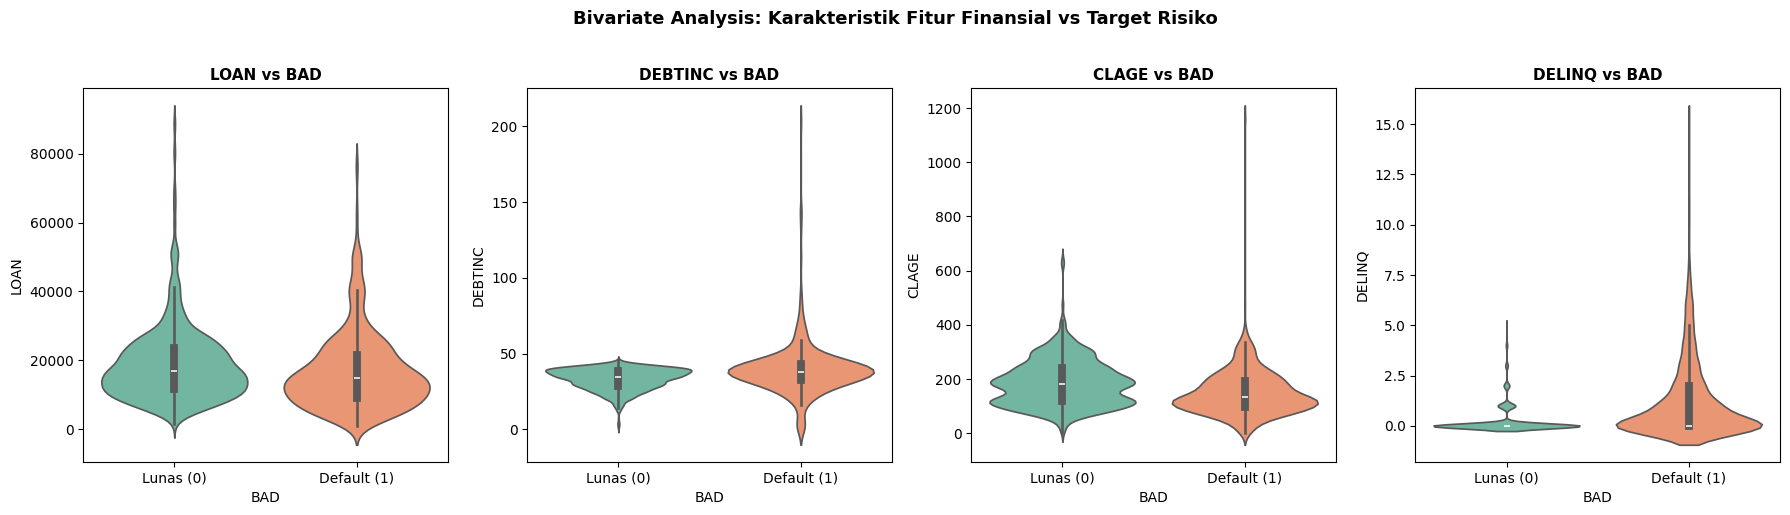


8. Matriks Korelasi Antar Fitur (Spearman)


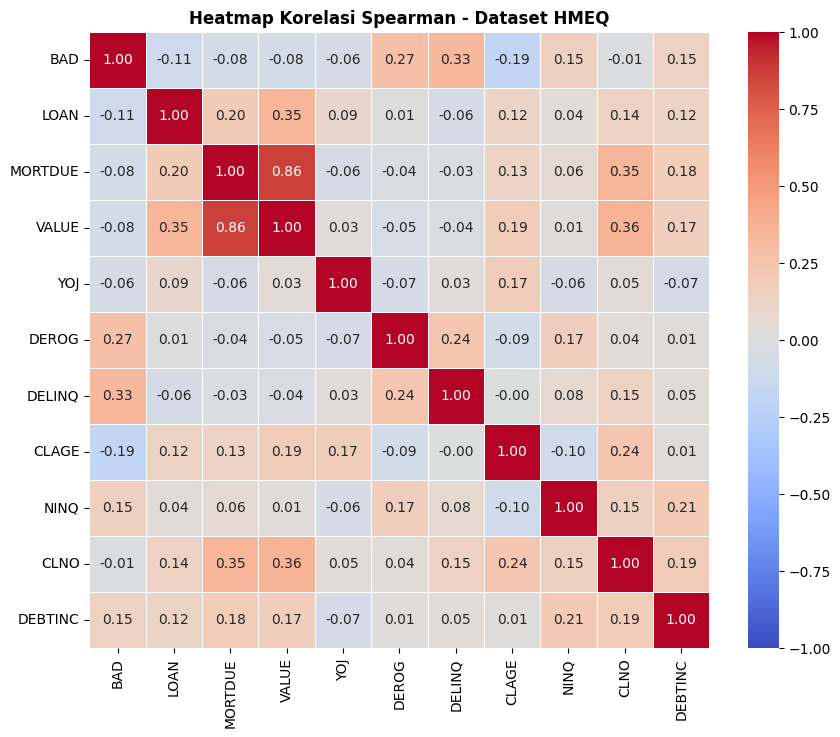

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# cek palet warna seaborn
try:
    PALETTE # type: ignore
except NameError:
    PALETTE = sns.color_palette("Set2")

print("\n1. Tipe Data Tiap Fitur")
display(df.dtypes.to_frame("Tipe Data"))

print("\n2. Statistik Deskriptif Fitur Numerik")
display(df.describe().round(2))

print("\n3. Statistik Deskriptif Fitur Kategorikal")
display(df.describe(include=['O']).round(2))

print("\n4. Distribusi Target BAD")
bad_counts = df["BAD"].value_counts().sort_index()
bad_summary = pd.DataFrame({
    "Jumlah": bad_counts,
    "Persentase (%)": (bad_counts / len(df) * 100).round(2)
})
bad_summary.index = ["BAD=0 (Lunas)", "BAD=1 (Default)"]
display(bad_summary)

print("\n5. Peta Missing Value Awal")
missing_summary = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Persentase (%)": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary["Missing"] >= 0].sort_values("Persentase (%)", ascending=False)
if not missing_summary.empty:
    display(missing_summary)
else:
    print("Missing Summary is Empty")

# snapshot data mentah untuk preprocessing
df_original = df.copy()

# visualisasi univariat untuk distribusi fitur numerik dalam histogram
num_cols_viz = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'BAD']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols_viz):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color=PALETTE[0], alpha=0.75, edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

for j in range(len(num_cols_viz), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribusi Seluruh Fitur Numerik Prediktor - HMEQ Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# visualisasi univariat untuk distribusi fitur numerik dengan bar chart
print("\n6. Visualisasi Distribusi Fitur Kategorikal")
cat_cols = [c for c in ["JOB", "REASON"] if c in df.columns]
fig, axes = plt.subplots(1, len(cat_cols), figsize=(14, 4))

if len(cat_cols) == 1:
    axes = [axes]

for i, col in enumerate(cat_cols):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i], color=PALETTE[1], alpha=0.8, edgecolor="white")
    axes[i].set_title(f"Distribusi Kategori {col}", fontweight="bold", fontsize=11)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].set_ylabel("Frekuensi")

plt.tight_layout()
plt.show()

# analisis bivariat untuk melihat hubungan fitur finansial utama dan tarket risiko
print("\n7. Analisis Perilaku Fitur Terhadap Risiko Gagal Bayar (BAD)")
num_cols_analysis = [c for c in ["LOAN", "DEBTINC", "CLAGE", "DELINQ"] if c in df.columns]

fig, axes = plt.subplots(1, len(num_cols_analysis), figsize=(18, 5))
if len(num_cols_analysis) == 1:
    axes = [axes]

for i, col in enumerate(num_cols_analysis):
    sns.violinplot(x='BAD', y=col, data=df, ax=axes[i], hue='BAD', palette="Set2", legend=False)
    axes[i].set_title(f"{col} vs BAD", fontsize=11, fontweight="bold")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Lunas (0)", "Default (1)"])

plt.suptitle("Bivariate Analysis: Karakteristik Fitur Finansial vs Target Risiko", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# analisis multivariat untuk identifikasi multikolinearitas melalui Spearman Heatmap
print("\n8. Matriks Korelasi Antar Fitur (Spearman)")
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr(method='spearman')

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Heatmap Korelasi Spearman - Dataset HMEQ", fontsize=12, fontweight="bold")
plt.show()

# **Unsupervised Analysis by Clustering**

Clustering akan menggunakan algoritma k-means dan bertujuan untuk **memetakan tingkat risiko nasabah (dari yang paling aman sampai yang paling berbahaya)** melalui beberapa dimensi yang diwakili oleh fitur-fitur yang representatif:
1. **Dimensi Karakter & Kedisiplinan (*Credit Behavior*):** Tampil pada variabel `DELINQ` (Jumlah Lini Kredit yang Sedang Menunggak) yang menggambarkan kekuatan kredit nasabah saat ini dan variabel `DEROG` (Jumlah Laporan Pelanggaran Kredit Serius) yang menggambarkan kekuatan kredit nasabah di masa lalu.
2. **Dimensi Beban Finansial (*Financial Capacity*):** Tampil pada variabel `DEBTINC` (Rasio Utang terhadap Pendapatan) untuk mengukur *solvency* di mana nasabah dengan rasio yang tinggi (misalnya > 40%) tidak memiliki kekuatan untuk menghadapi guncangan ekonomi darurat sehingga sangat rentan bergeser ke kelompok berisiko tinggi.
3. **Dimensi Kematangan Kredit (*Credit Maturity*):** Tampil pada variabel `CLAGE` (Usia Lini Kredit Tertua dalam Bulan) yang menggambarkan ketahanan nasabah dalam menghadapi berbagai musim ekonomi seiring waktu di mana kalau angkanya besar  berarti mereka lebih tahan uji daripada nasabah dengan angka yang kecil (terdapat *uncertainty risk* yang lebih tinggi).
4. **Dimensi Paparan Risiko (*Risk Exposure*):** Tampil pada variabel `LOAN` (Jumlah Pinjaman yang Diajukan) karena menggambarkan nominal pinjaman murni di mana nasabah yang kapasitas finasialnya pas-pasan tetapi mengajukan pinjaman dalam jumlah besar akan membuat magnitudo risiko kerugian (*loss given default*) melonjak secara eksponensial.

Clustering akan menggunakan variabel `DELINQ`, `DEROG`, `DEBTINC`, `CLAGE`, `LOAN` sebagai bagian dari keempat dimensi yang akan ditinjau untuk menggambarkan tingkat risiko nasabah (dari yang paling aman sampai yang paling berbahaya).

## **Data Preprocessing for Clustering**

Run cell di bawah ini untuk melakukan pemrosesan awal (*preprocessing*) murni pada fitur risiko terpilih:

1. Isolasi lima fitur risiko prediktor utama (`DELINQ`, `DEROG`, `DEBTINC`, `CLAGE`, `LOAN`).
2. Transformasi logaritmik (`np.log1p`) untuk menjinakkan kecondongan (*skewness*) sebaran data.
3. Penanganan *outliers* ekstrem melalui *capping* (*Winsorization*) pada batas atas persentil ke-99 (P-99).
4. Standarisasi skala nilai menggunakan `StandardScaler` untuk menyetarakan bobot dimensi jarak geometris.
5. Imputasi data yang hilang (*missing value*) menggunakan pendekatan kedekatan spasial `KNNImputer` dengan nilai K = 5.
6. Pemetaan ulang integritas data lewat peta *missing value* pasca-pipeline untuk memastikan kebersihan data 100%.
7. Visualisasi univariat sebaran data baru hasil penjinakan melalui histogram (*bar chart*) terstandardisasi.

Transformasi data di fase ini diharapkan dapat menjadi fondasi input yang bersih, simetris, dan setara secara skala koordinat agar algoritma K-Means dapat mengidentifikasi dan membentuk kluster tingkat risiko nasabah secara tegas dan optimal.


Header Data Setelah Preprocessing


,DELINQ,DEROG,DEBTINC,CLAGE,LOAN
0,-0.492886,-0.375193,0.207951,-0.956362,-4.664416
1,1.947818,-0.375193,-3.865729,-0.485559,-4.372369
2,-0.492886,-0.375193,-1.285909,-0.108110,-4.122168
3,-0.004745,-0.375193,-1.112150,-0.692407,-4.122168
4,-0.492886,-0.375193,0.207951,-0.976627,-3.903309



Peta Missing Value Sekarang


,Missing,Persentase (%)
DELINQ,0,0.0
DEROG,0,0.0
DEBTINC,0,0.0
CLAGE,0,0.0
LOAN,0,0.0



Distribusi Fitur Setelah Preprocessing


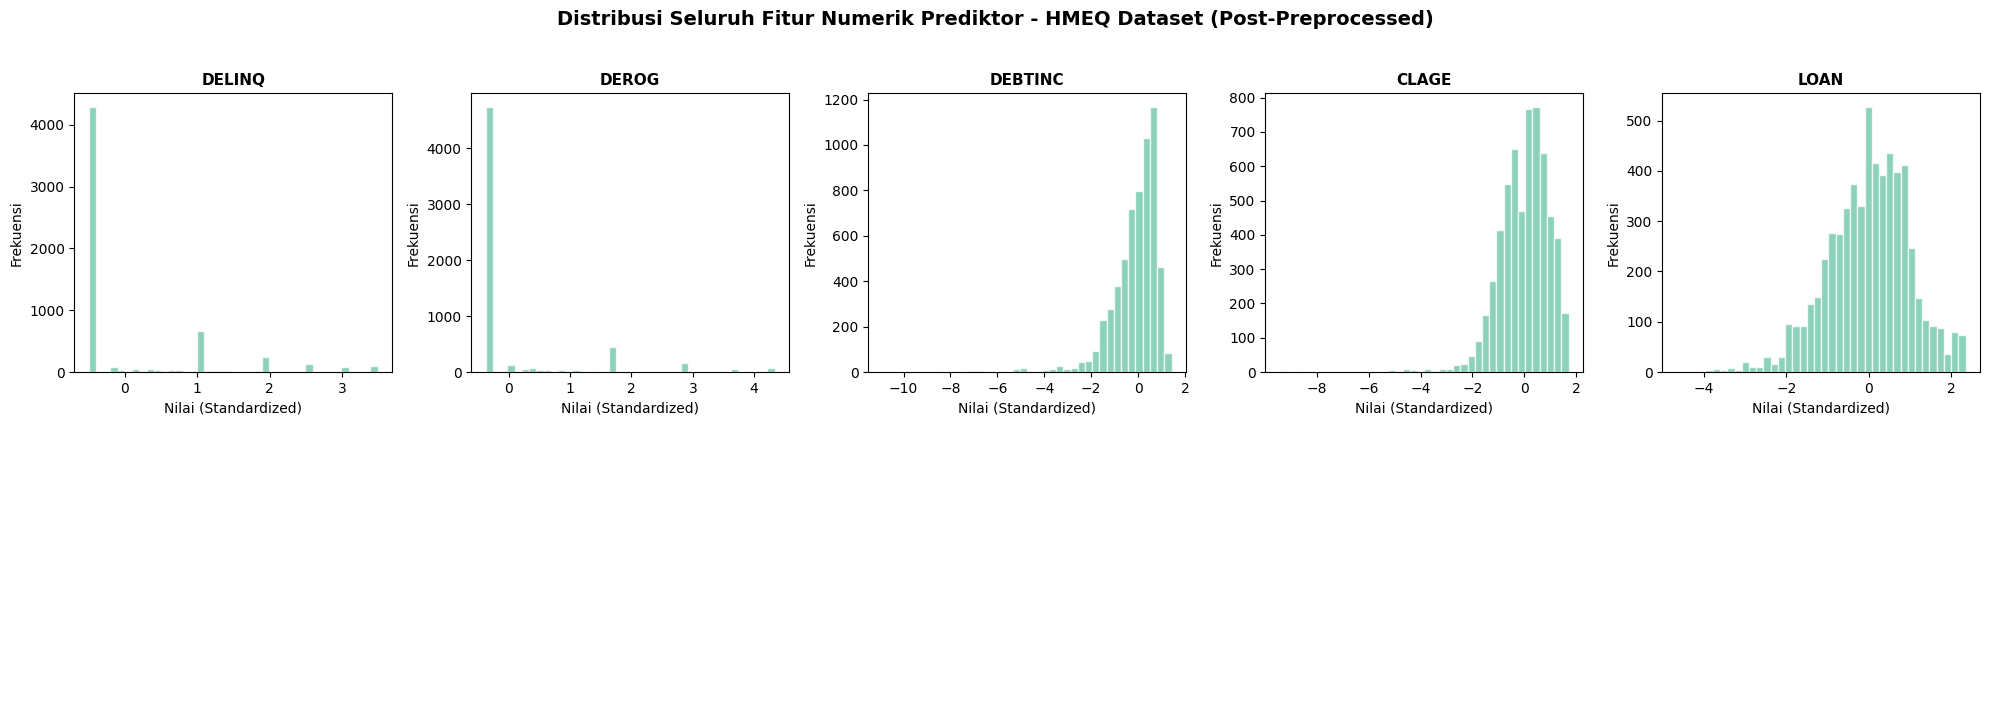

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# cek palet warna seaborn
try:
    PALETTE
except NameError:
    PALETTE = sns.color_palette("Set2")

# df_original dan isolasi 5 fitur risiko pilihan
df_original = df.copy()
df_preprocessed_clustering = df_original[['DELINQ', 'DEROG', 'DEBTINC', 'CLAGE', 'LOAN']].copy()

# transformasi logaritmik (np.log1p) untuk menjinakkan skewnes
for col in df_preprocessed_clustering.columns:
    df_preprocessed_clustering[col] = np.log1p(df_preprocessed_clustering[col])

# handle outliers ekstrem via capping (winsorization) pada P-99
for col in df_preprocessed_clustering.columns:
    upper_limit = df_preprocessed_clustering[col].quantile(0.99)
    df_preprocessed_clustering[col] = df_preprocessed_clustering[col].clip(upper=upper_limit)

# standarisasi
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_preprocessed_clustering)
df_scaled = pd.DataFrame(scaled_array, columns=df_preprocessed_clustering.columns)

# imputasi missing value pakai KNN Imputer (K = 5)
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df_scaled)

# hasil akhir dimasukkan ke DataFrame target
df_preprocessed_clustering = pd.DataFrame(imputed_array, columns=df_preprocessed_clustering.columns)

print("\nHeader Data Setelah Preprocessing")
display(df_preprocessed_clustering.head())

# peta missing value setelah preprocessing
print("\nPeta Missing Value Sekarang")
missing_summary = pd.DataFrame({
    "Missing": df_preprocessed_clustering.isnull().sum(),
    "Persentase (%)": (df_preprocessed_clustering.isnull().sum() / len(df_preprocessed_clustering) * 100).round(2)
})
missing_summary = missing_summary[missing_summary["Missing"] >= 0].sort_values("Persentase (%)", ascending=False)
if not missing_summary.empty:
    display(missing_summary)
else:
    print("Missing Summary is Empty")

# distribusi data setelah preprocessing dengan histogram (bar chart)
print("\nDistribusi Fitur Setelah Preprocessing")
num_cols_viz = [c for c in df_preprocessed_clustering.select_dtypes(include=[np.number]).columns]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols_viz):
    data = df_preprocessed_clustering[col].dropna()
    axes[i].hist(data, bins=40, color=PALETTE[0], alpha=0.75, edgecolor="white")
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Nilai (Standardized)")
    axes[i].set_ylabel("Frekuensi")

for j in range(len(num_cols_viz), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribusi Seluruh Fitur Numerik Prediktor - HMEQ Dataset (Post-Preprocessed)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## **Metode Clustering: Algoritma K-Means**

Run cell di bawah ini untuk mengevaluasi jumlah kelompok optimal secara objektif dan melakukan klustering final:

1. Menghitung nilai *Within-Cluster Sum of Squares* (WCSS) serta tiga skor metrik evaluasi internal (*Silhouette*, *Davies-Bouldin*, dan *Calinski-Harabasz*) secara simultan melalui proses *looping* rentang $K=1$ hingga $K=10$.
2. Visualisasi komparatif hasil keempat metrik evaluasi dalam bentuk *grid plot* 2x2 untuk analisis perbandingan geometri kluster yang komprehensif.
3. Penentuan jumlah kluster terbaik (`BEST_K`) secara otomatis berdasarkan pencarian nilai skor *Silhouette* tertinggi (*maximum score*).
4. Melakukan *fitting* dan prediksi final algoritma K-Means menggunakan nilai `BEST_K` hasil optimasinya.
5. Memetakan (*mapping*) label `Cluster_Risiko` hasil prediksi final kembali ke data asli (`df_original`) untuk kebutuhan analisis karakteristik kelompok (*segment profiling*).

Hasil pelabelan otomatis dari fase pemodelan ini diharapkan dapat membentuk segmentasi risiko nasabah yang jujur sesuai struktur alami data sebagai anchor bagi sensitivitas fitur prediktor penting untuk meningkatkan performa klasifikasi.


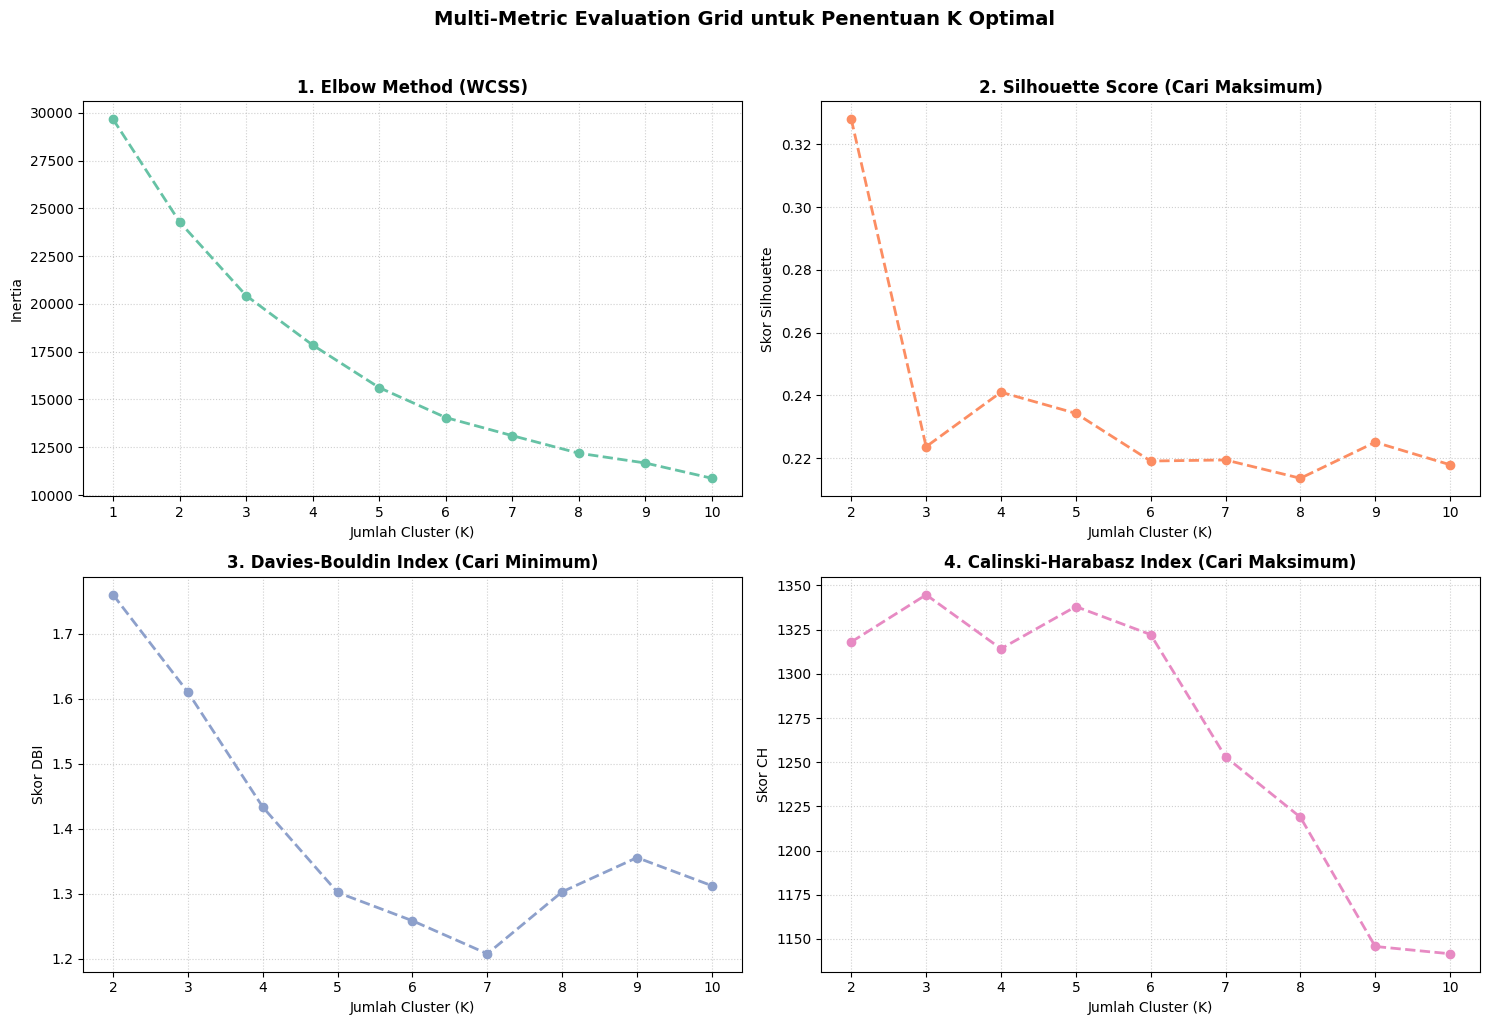

EVALUASI OTOMATIS:
-> Skor Silhouette Terbaik: 0.3280
-> Algoritma merekomendasikan K = 2 sebagai jumlah kluster paling optimal secara geometri.

Menjalankan K-Means dengan K=2...

Kolom 'Cluster_Risiko' berhasil dipetakan ke df_original.
Sampel hasil akhir data berdasarkan K optimal:


,DELINQ,DEROG,DEBTINC,CLAGE,LOAN,Cluster_Risiko
0,0.0,0.0,NaN,94.366667,1100,0
1,2.0,0.0,NaN,121.833333,1300,1
2,0.0,0.0,NaN,149.466667,1500,0
3,NaN,NaN,NaN,NaN,1500,1
4,0.0,0.0,NaN,93.333333,1700,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# cek palet warna seaborn
try:
    PALETTE
except NameError:
    PALETTE = sns.color_palette("Set2")

# inisialisasi penampung skor metrik evaluasi
wcss = []
silhouette_scores = []
dbi_scores = []
ch_scores = []

# tentukan rentang K yang diuji (K=1 hanya possible untuk WCSS)
k_range = range(1, 11)
k_metrics_range = range(2, 11) # evaluasi internal butuh minimal 2 cluster

# loop untuk mencari nilai K dengan performa terbaik
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init="auto")
    labels = kmeans.fit_predict(df_preprocessed_clustering)
    wcss.append(kmeans.inertia_)

    if k >= 2:
        silhouette_scores.append(silhouette_score(df_preprocessed_clustering, labels))
        dbi_scores.append(davies_bouldin_score(df_preprocessed_clustering, labels))
        ch_scores.append(calinski_harabasz_score(df_preprocessed_clustering, labels))

# perbandingan hasil 4 metrik evaluasi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

# WCSS (Elbow Method)
axes[0].plot(k_range, wcss, marker='o', linestyle='--', color='#66c2a5', linewidth=2)
axes[0].set_title('1. Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_range)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Silhouette Score (semakin tinggi, semakin baik)
axes[1].plot(k_metrics_range, silhouette_scores, marker='o', linestyle='--', color='#fc8d62', linewidth=2)
axes[1].set_title('2. Silhouette Score (Cari Maksimum)', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (K)')
axes[1].set_ylabel('Skor Silhouette')
axes[1].set_xticks(k_metrics_range)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Davies-Bouldin Index (semakin rendah, semakin baik)
axes[2].plot(k_metrics_range, dbi_scores, marker='o', linestyle='--', color='#8da0cb', linewidth=2)
axes[2].set_title('3. Davies-Bouldin Index (Cari Minimum)', fontweight='bold')
axes[2].set_xlabel('Jumlah Cluster (K)')
axes[2].set_ylabel('Skor DBI')
axes[2].set_xticks(k_metrics_range)
axes[2].grid(True, linestyle=':', alpha=0.6)

# Calinski-Harabasz Index (semakin tinggi, semakin baikk)
axes[3].plot(k_metrics_range, ch_scores, marker='o', linestyle='--', color='#e78ac3', linewidth=2)
axes[3].set_title('4. Calinski-Harabasz Index (Cari Maksimum)', fontweight='bold')
axes[3].set_xlabel('Jumlah Cluster (K)')
axes[3].set_ylabel('Skor CH')
axes[3].set_xticks(k_metrics_range)
axes[3].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Multi-Metric Evaluation Grid untuk Penentuan K Optimal", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# cari nilai K terbaik berdasarkan silhouette score
best_k_idx = np.argmax(silhouette_scores)
BEST_K = k_metrics_range[best_k_idx]

print(f"EVALUASI OTOMATIS:")
print(f"-> Skor Silhouette Terbaik: {silhouette_scores[best_k_idx]:.4f}")
print(f"-> Algoritma merekomendasikan K = {BEST_K} sebagai jumlah kluster paling optimal secara geometri.")

# fit k-means terhadap dataset dengan K terbaik
print(f"\nMenjalankan K-Means dengan K={BEST_K}...")
kmeans_final = KMeans(n_clusters=BEST_K, init='k-means++', random_state=42, n_init="auto")
cluster_labels = kmeans_final.fit_predict(df_preprocessed_clustering)

# mapping cluster ke df_original untuk dilakukan profiling
df_original['Cluster_Risiko'] = cluster_labels

print("\nKolom 'Cluster_Risiko' berhasil dipetakan ke df_original.")
print("Sampel hasil akhir data berdasarkan K optimal:")
display(df_original[['DELINQ', 'DEROG', 'DEBTINC', 'CLAGE', 'LOAN', 'Cluster_Risiko']].head())

### **Analisis Pemilihan $K$ Optimal**

**Tabel Pemetaan Metrik Evaluasi K-Optimal (HMEQ Dataset)**

| Metrik Evaluasi | $K$ Optimal | Pola Geometri Data yang Ditangkap | Pertimbangan |
| --- | --- | --- | --- |
| **Silhouette Score** | **$K = 2$** | Pemisah ruang tegas dan minim *overlapping*. | Pemisahan cluster harus deterministik (tegas). |
| **Calinski-Harabasz (CH)** | **$K = 3$** | Menunjukkan puncak tertinggi. | Pembagian nasabah menjadi 3 tingkat (Aman, Moderat, Berbahaya). |
| **Davies-Bouldin Index (DBI)** | **$K = 7$** | Grafik menurun hingga $K=7$ | Memicu *over-segmentation* yang tidak diperlukan. |

**Apa Dasar Dari Penggunaan Silhouette Score?**

Penggunaan **Silhouette Score** yang mendapatkan $K = 2$ adalah keputusan metodologis terbaik karena metrik ini mengevaluasi dua komponen geometri ruang secara simultan, yaitu kedekatan internal objek dengan kelompoknya (*cohesion*) sekaligus jarak batas antar-kelompok (*separation boundary*). Berikut adalah perbandingan hasil dengan metode lainnya:
1. *Calinski-Harabasz* bias terhadap kluster yang berukuran seragam.
2. *Davies-Bouldin Index* menjebak model ke dalam *over-segmentation* ($K = 7$).
3. *Silhouette Score* menunjukkan jumlah pembagian kluster yang paling minimal dan tegas.

Teknik penentuan $K$ dinamis berbasis skor *Silhouette* tertinggi memastikan bahwa metode *clustering* yang digunakan berdiri di atas fondasi matematika yang jujur, objektif, dan interpretastif.

## **Interpretasi Hasil Clustering**

Run cell di bawah ini untuk membedah karakteristik alami sebelum membangun *Customer Persona* dari masing-masing kluster risiko tanpa melibatkan intervensi variabel target:

1. Isolasi variabel target (`BAD`) dan penanda kluster (`Cluster_Risiko`) untuk memastikan proses konstruksi profil nasabah berjalan steril dan terhindar dari bias informasi.
2. Kalkulasi ringkasan statistik multi-metrik (*mean* untuk melihat tren agregat dan *median* untuk meredam outliers) pada seluruh fitur numerik asli untuk menangkap fakta objektif finansial nasabah.
3. Ekstraksi distribusi proporsi fitur kategorikal berbasis teks (`JOB` dan `REASON`) melalui *cross-tabulation* per  kluster.
4. Kompilasi tabel profil setelah mendapatkan rekap statistik dilakukan untuk mempermudah analisis komparatif dan melihat kontras perbedaan perilaku antar-kelompok nasabahnya.

Hasil eksplorasi profil dari fase deskriptif ini diharapkan dapat menjembatani pengelompokan nasabah berbasis heuristik sebelum dilakukan *Integration Analysis* dengan hasil klasifikasi.

In [ ]:
# kolom yang harus diabaikan agar mencemari proses profiling
ignored_columns = ['BAD', 'Cluster_Risiko']

# agregasi fitur numerik (pakai mean dan median untuk menangkap skewness asli)
num_cols = [c for c in df_original.select_dtypes(include=[np.number]).columns if c not in ignored_columns]

print("\n1. Ringkasan Statistik Fitur Numerik Asli:")
# memakai mean untuk tren agregat dan median untuk mengamankan data dari skewness ekstrem
numeric_profile = df_original.groupby('Cluster_Risiko')[num_cols].agg(['mean', 'median']).T
display(numeric_profile.round(2))

# distribusi fitur kategorikal pada kolom REASON dan JOB
cat_cols = [c for c in df_original.select_dtypes(include=['object', 'category']).columns if c not in ignored_columns]

if cat_cols:
    print("\n2. Distribusi Proporsi Fitur Kategorikal (dalam % per cluster):")
    for col in cat_cols:
        print(f"\nFitur: {col}")
        categorical_profile = pd.crosstab(df_original[col], df_original['Cluster_Risiko'], normalize='columns') * 100
        display(categorical_profile.round(2))
else:
    print("\n2. Tidak ditemukan fitur kategorikal pada dataset.")



1. Ringkasan Statistik Fitur Numerik Asli:


Cluster_Risiko          0         1
LOAN    mean     19448.45  15568.32
        median   17100.00  13400.00
MORTDUE mean     75473.19  67384.00
        median   66559.50  61426.00
VALUE   mean    105150.29  89002.52
        median   91307.00  81059.50
YOJ     mean         9.12      8.19
        median       7.00      6.00
DEROG   mean         0.03      1.20
        median       0.00      1.00
DELINQ  mean         0.09      1.90
        median       0.00      2.00
CLAGE   mean       184.63    161.27
        median     178.15    144.98
NINQ    mean         1.07      1.65
        median       1.00      1.00
CLNO    mean        20.99     22.49
        median      20.00     22.00
DEBTINC mean        33.89     33.20
        median      34.91     34.21


2. Distribusi Proporsi Fitur Kategorikal (dalam % per cluster):

Fitur: REASON


Cluster_Risiko,0,1
REASON,,
DebtCon,69.45,66.42
HomeImp,30.55,33.58



Fitur: JOB


Cluster_Risiko,0,1
JOB,,
Mgr,12.78,16.18
Office,17.40,14.01
Other,40.92,46.21
ProfExe,23.67,17.93
Sales,1.76,2.50
Self,3.46,3.17


### **Kluster & Customer Persona**

Diketahui bersama bahwa dataset secara optimal terbagi menjadi 2 kluster berdasarkan _**Multi-Metric Evaluation Grid berbasis Silhouette Score**_. Melalui ringkasan statistik fitur numerik asli (kombinasi *mean* dan *median*) dan proporsi fitur kategorikal, berikut adalah hasil dekonstruksi karakteristik untuk setiap kluster nasabah:

### **1. Kluster 0: _The Prudent Prime Borrower_** (Nasabah Premium Berisiko Rendah)

Kluster ini merepresentasikan nasabah dengan karakteristik yang *dikatakan layak untuk disetujui pengajuan home equity-nya* karena memiliki kondisi finansial yang stabil dan rekam jejak kredit yang bersih.

* **Karakteristik Finansial:** Kelompok ini mengajukan nominal pinjaman yang jauh lebih besar (Median `LOAN`: $\$17,100$) karena didukung oleh nilai aset agunan rumah yang tinggi (Median `VALUE`: $\$91,307$).
* **Perilaku Kredit (*Credit Behavior*):** **Aman secara historis.** Nilai *median* untuk tunggakan berjalan (`DELINQ`) dan catatan buruk di lembaga kliring (`DEROG`) berada  di angka 0.00 mutlak. Kelompok ini juga memiliki kematangan durasi pengambilan kredit di masa lalu(Median `CLAGE`: 178.15 bulan).
* **Demografis:** Didominasi oleh pekerja profesional/eksekutif (`ProfExe`: 23.67%) dan pegawai administrasi (`Office`: 17.40%) dengan loyalitas kerja yang dapat dikatakan stabil (Median `YOJ`: 7 tahun).

### **2. Kluster 1: _The Distressed Subprime Borrowers_** (Nasabah Defisit Berisiko Tinggi)

Kelompok ini merepresentasikan nasabah dengan karakteristik yang *harus diwaspadai oleh perbankan ketika mengajukan home equity* karena memiliki tekanan finansial akut dan masalah kedisiplinan dalam melakukan pembayaran.

* **Karakteristik Finansial:** Kelompok ini mengajukan pinjaman dengan nominal yang lebih kecil (Median `LOAN`: $\$13,400$) karena setara dengan nilai aset rumah mereka yang lebih rendah (Median `VALUE`: $\$81,059.50$).
* **Perilaku Kredit (*Credit Behavior*):** **Rawan secara historis.** Kelompok ini kebanyakan memiliki 2 kali tunggakan berjalan (Median `DELINQ`: 2) dan 1 catatan pelanggaran hukum kredit (Median `DEROG`: 1.00). Usia riwayat kredit mereka juga cenderung lebih muda (Median `CLAGE`: 144.98 bulan).
* **Demografis**: Proporsi pekerja berkategori *Manager* (`Mgr`: 16.18%) dan *Sales* lebih tinggi dibandingkan kluster 0, namun memiliki stabilitas tahun bekerja yang lebih rendah (Median `YOJ`: 6 tahun).

---

**Temuan-Temuan Heuristik Berdasarkan Hasil Penerapan Clustering**

* Meskipun kita memasukkan 5 fitur risiko ke dalam algoritma K-Means, pembentukan batas kluster secara geometris murni dipengaruhi oleh **variabel rekam jejak moralitas kredit** (`DELINQ`, `DEROG`, `CLAGE`) dan **skala nominal pinjaman** (`LOAN`). Ketiga fitur moralitas tersebut memiliki kontras perbedaan yang sangat ekstrem antar-kluster.
* Menariknya, fitur rasio utang terhadap pendapatan (`DEBTINC`) yang dipakai pada K-Means ternyata memiliki nilai *median* yang hampir kembar di kedua kelompok (~34.9% vs ~34.2%) yang mana ini membuktikan secara empiris bahwa nasabah berisiko tinggi (kluster 1) sebenarnya memiliki kapasitas beban utang yang mirip dengan nasabah berisiko rendah (kluster 0) sehingga ternyata `DEBTINC` tidak sensitif terhadap pengelompokan natural pada dataset HMEQ.
* Melalui perluasan analisis pada 12 fitur asli di tahap *profiling*, terdeteksi adanya korelasi linear yang sehat pada fitur luar yang tidak dilatih di K-Means yaitu pada nasabah di kluster 0 yang mengambil pinjaman (`LOAN`) yang lebih besar ternyata secara natural diimbangi dengan kepemilikan nilai aset rumah (`VALUE`) yang lebih tinggi juga.
* Distribusi alasan pengajuan pinjaman (`REASON`) terbukti identik di kedua kluster (didominasi oleh *Debt Consolidation* sebesar 66-69%). Hal ini mengonfirmasi bahwa keputusan awal untuk mengeliminasi fitur-fitur kategorikal dari proses *fitting* jarak Euclidean adalah langkah yang tepat karena fitur tersebut tidak memiliki daya pembeda struktural.

# **Supervised Analysis by Classification**

Klasifikasi yang dilakukan berfokus untuk membedakan status kelayakan kredit nasabah ke dalam target biner `BAD` ($1$ menyatakan nasabah *default* atau gagal bayar dan $0$ menyatakan nasabah berhasil melunasi pinjaman). Untuk menghasilkan analisis yang objektif dan komprehensif, analisis dilakukan dengan mengadopsi dua paradigma teknologi yang berbeda:

* **Pendekatan Klasik (*Parametric/Statistical ML*): Linear Discriminant Analysis (LDA)** yaitu algoritma yang mengandalkan landasan statistik yang kaku, membutuhkan efisiensi fitur yang tinggi, serta sangat patuh pada asumsi distribusi data.
* **Pendekatan Modern (*Non-Parametric/Deep Learning*): Artificial Neural Network (ANN)** yaitu pendekatan yang memanfaatkan arsitektur komputasi modern yang fleksibel, bebas dari asumsi klasik, serta memiliki kapasitas tinggi untuk mengekstrak hubungan non-linear yang kompleks secara mandiri.

Perbedaan fundamental dalam cara kerja kedua algoritma ini melahirkan strategi pemisahan variabel (*feature selection*) dan jalur *preprocessing* yang bertolak belakang di mana jalur ANN dikondisikan secara **maksimalis** dengan melahap seluruh informasi dataset sedangkan jalur LDA dikondisikan secara **minimalis** melalui reduksi fitur yang ketat untuk menjaga kestabilan matematis.

**Matriks Perlakukan Fitur untuk Pendekatan Klasik (LDA) dan Modern (ANN)**

| Nama Fitur | Tipe Data | LDA | ANN | One-Hot Encoding | Transformasi Log | Winsorization | Standard Scaling | KNN Imputation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| **`LOAN`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`MORTDUE`** | Numerik | ✗ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`VALUE`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`YOJ`** | Numerik | ✗ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`DEROG`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`DELINQ`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`CLAGE`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`NINQ`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`CLNO`** | Numerik | ✗ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`DEBTINC`** | Numerik | ✓ | ✓ | ✗ | ✓ | ✓ | ✓ | ✓ |
| **`JOB`** | Kategorikal | ✓ | ✓ | ✓ | ✗ | ✗ | ✓* | ✗ |
| **`REASON`** | Kategorikal | ✗ | ✓ | ✓ | ✗ | ✗ | ✓* | ✗ |

## **Data Preprocessing for Classification**

Run cell di bawah ini untuk melakukan *preprocessing* dataset secara paralel pada pendekatan klasik (LDA) dan modern (ANN):

1. Mengamankan baris kosong pada fitur kategorikal (`JOB` dan `REASON`) dengan mengonversinya menjadi kategori `'Unknown'` untuk mencegah bias dan dilanjutkan dengan transformasi *One-Hot Encoding*.
2. Memisahkan variabel berdasarkan kebutuhan arsitektur model (8 fitur untuk jalur minimalis LDA dan 12 fitur komplit untuk jalur maksimalis ANN) serta melakukan splitting data secara murni (*Train:Test* 80:20 untuk LDA; *Train:Val:Test* 70:10:20 untuk ANN) menggunakan parameter `stratify=y` guna mengunci kestabilan rasio kelas target `BAD`.
3. Menampilkan *countplot* dan detail persentase detail kelas minoritas (`BAD=1`) di kelima kelompok subset data untuk membuktikan homogenitas sebaran distribusi risiko.
4. Menerapkan fungsi `np.log1p` (Transformasi Logaritmik) secara independen pada fitur-fitur numerik pilihan di setiap subset untuk mereduksi tingkat kecondongan (*skewness*) sebaran data.
5. Menghitung nilai batas atas di P-99 (*Capping / Winsorization*) murni hanya dari data latih (*Train Set*) kemudian menggunakannya untuk memotong data *Train*, *Validation*, dan *Test Set* demi menghindari kebocoran (*data leakage*).
6. Menggunakan `StandardScaler` (Standarisasi) untuk menyetarakan bobot seluruh variabel prediktor (baik numerik asli maupun kolom biner hasil encoding) ke dalam skala Z-Score baku.
7. Mengisi *missing value* pada kolom numerik yang telah terstandardisasi menggunakan pendekatan jarak spasial `KNNImputer` dengan konfigurasi tetangga terdekat K = 5.
8. Memetakan kembali ringkasan data kosong untuk menjamin status kebersihan data secara menyeluruh di semua subset dan visualisasi fungsi histogram dinamis untuk meninjau hasil akhir penyelarasan distribusi fitur.

Tahapan berlapis dan terisolasi ini dirancang untuk menghasilkan struktur input yang steril, bebas dari kontaminasi bias dan leakage, dan siap dioptimalkan secara adil oleh setiap classifier baik LDA maupun ANN.

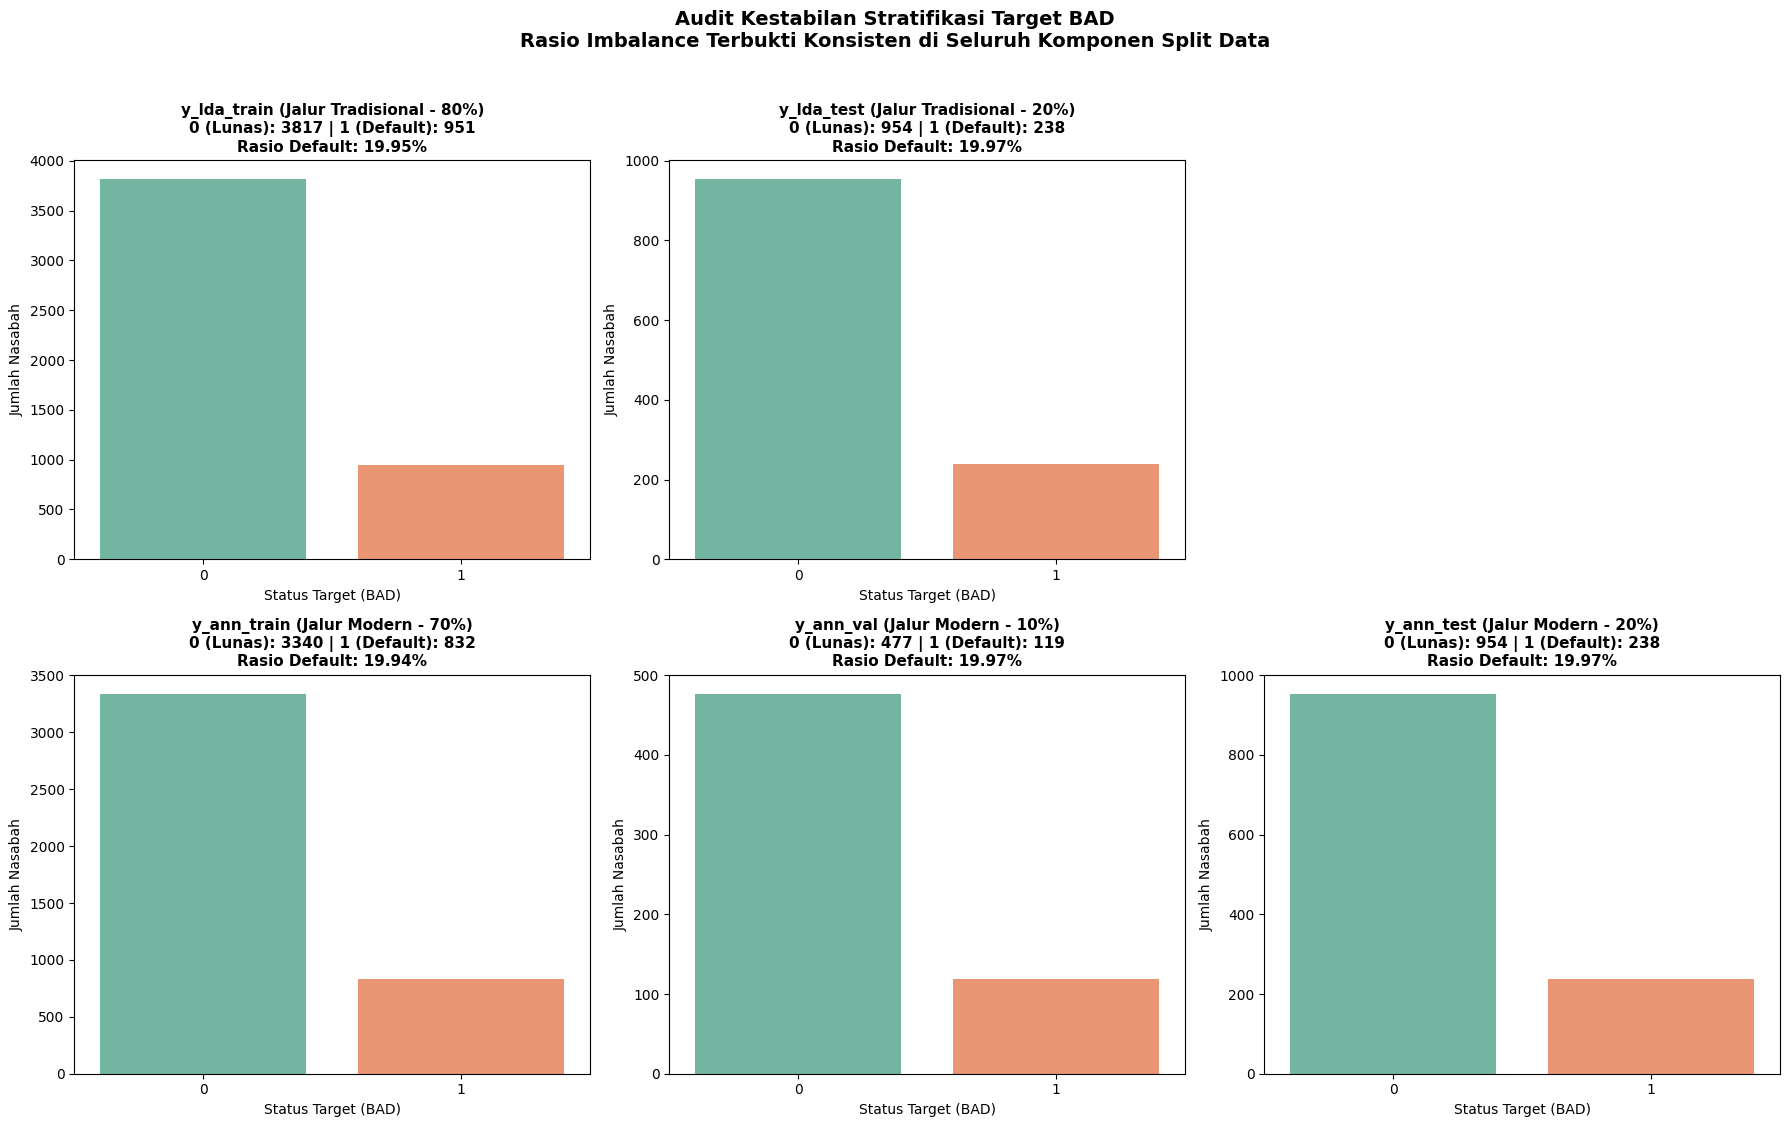


Peta Missing Value di x_lda_train:


,Missing,Persentase (%)
LOAN,0,0.0
VALUE,0,0.0
DEROG,0,0.0



Peta Missing Value di x_lda_test:


,Missing,Persentase (%)
LOAN,0,0.0
VALUE,0,0.0
DEROG,0,0.0



Peta Missing Value di x_ann_train:


...


Peta Missing Value di x_ann_val:


,Missing,Persentase (%)
LOAN,0,0.0
MORTDUE,0,0.0
VALUE,0,0.0



Peta Missing Value di x_ann_test:


,Missing,Persentase (%)
LOAN,0,0.0
MORTDUE,0,0.0
VALUE,0,0.0



Memproses Grafik Distribusi untuk: x_lda_train


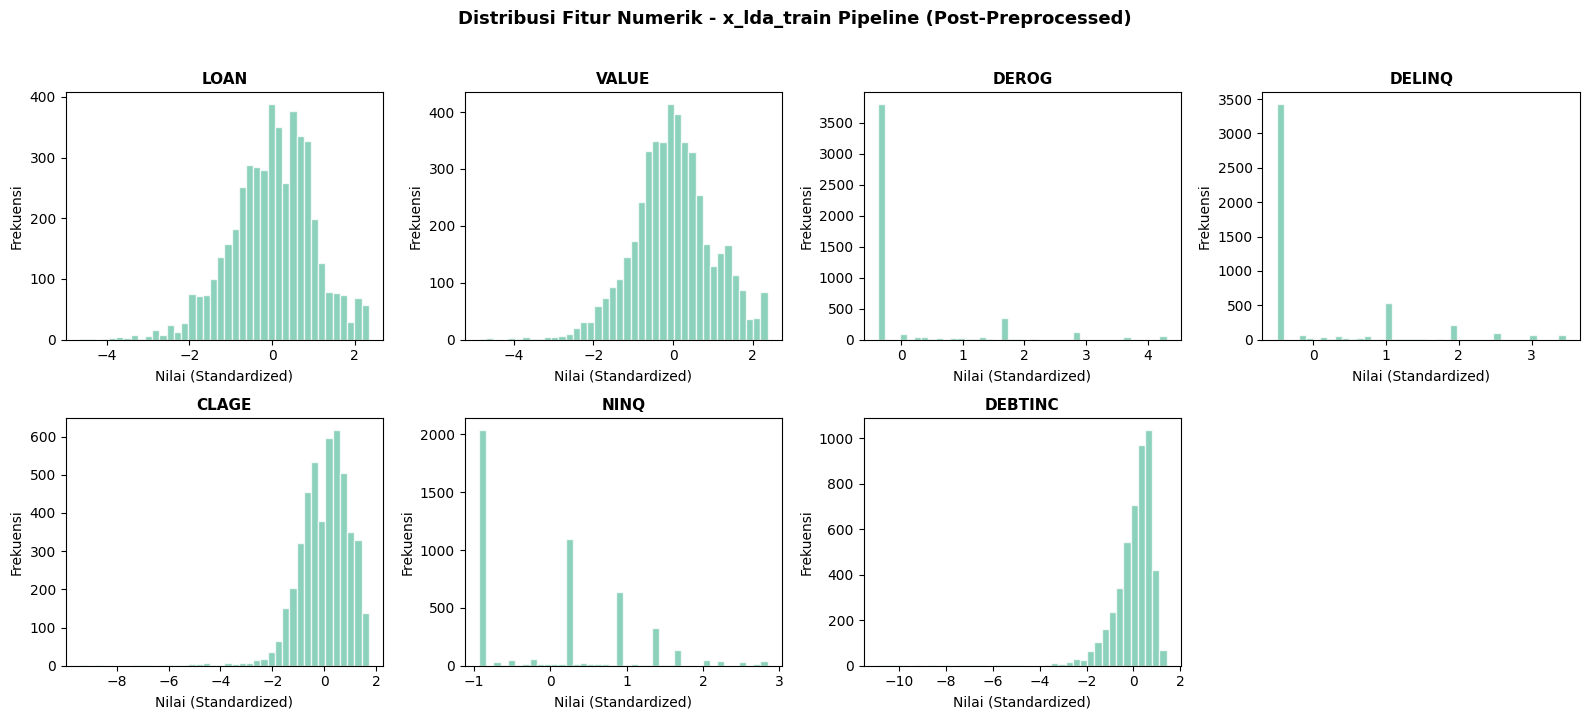


Memproses Grafik Distribusi untuk: x_lda_test


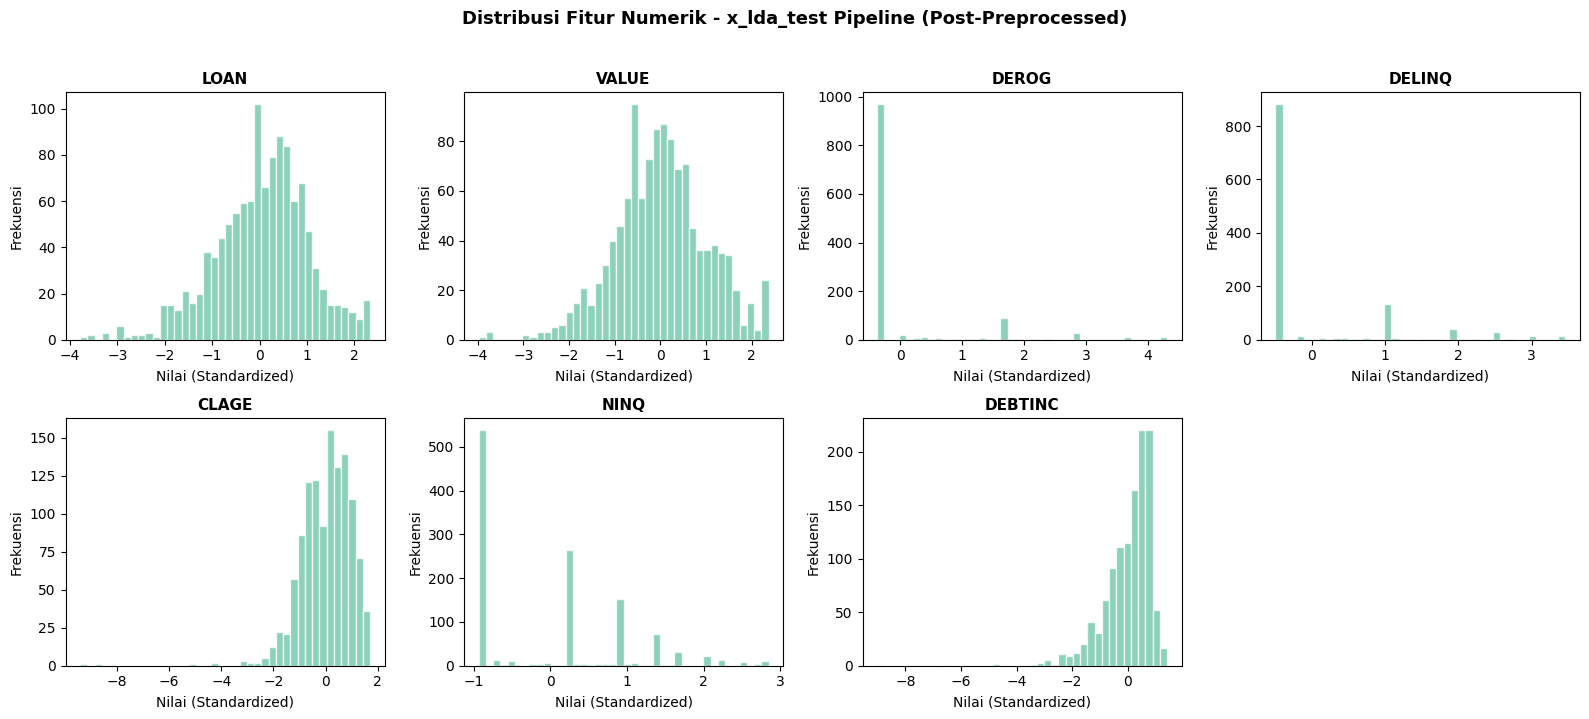


Memproses Grafik Distribusi untuk: x_ann_train


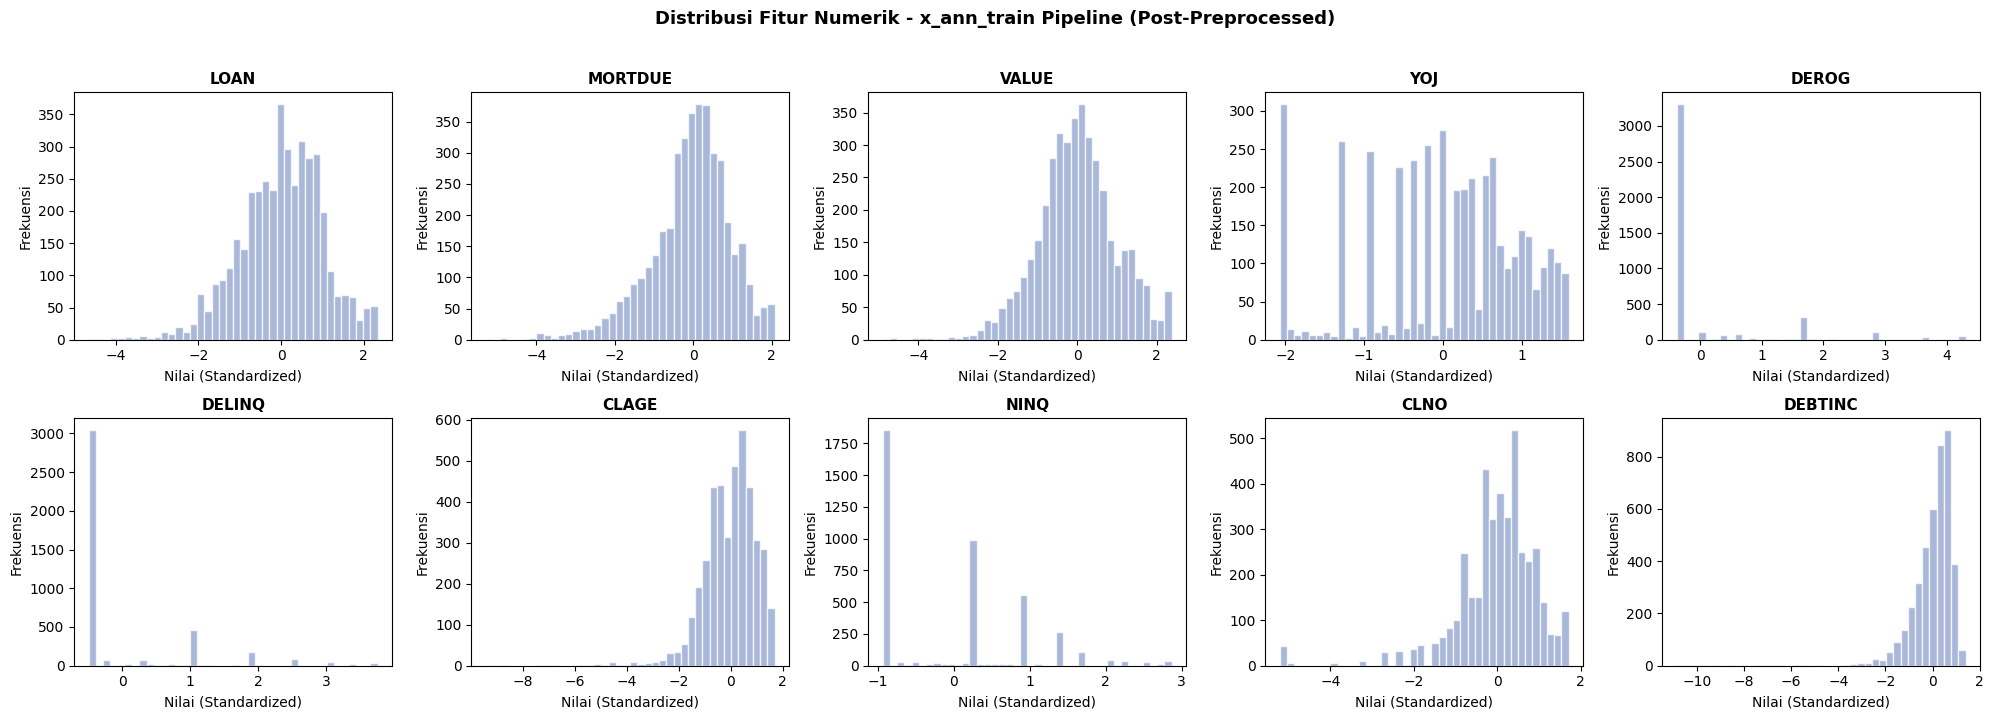


Memproses Grafik Distribusi untuk: x_ann_val


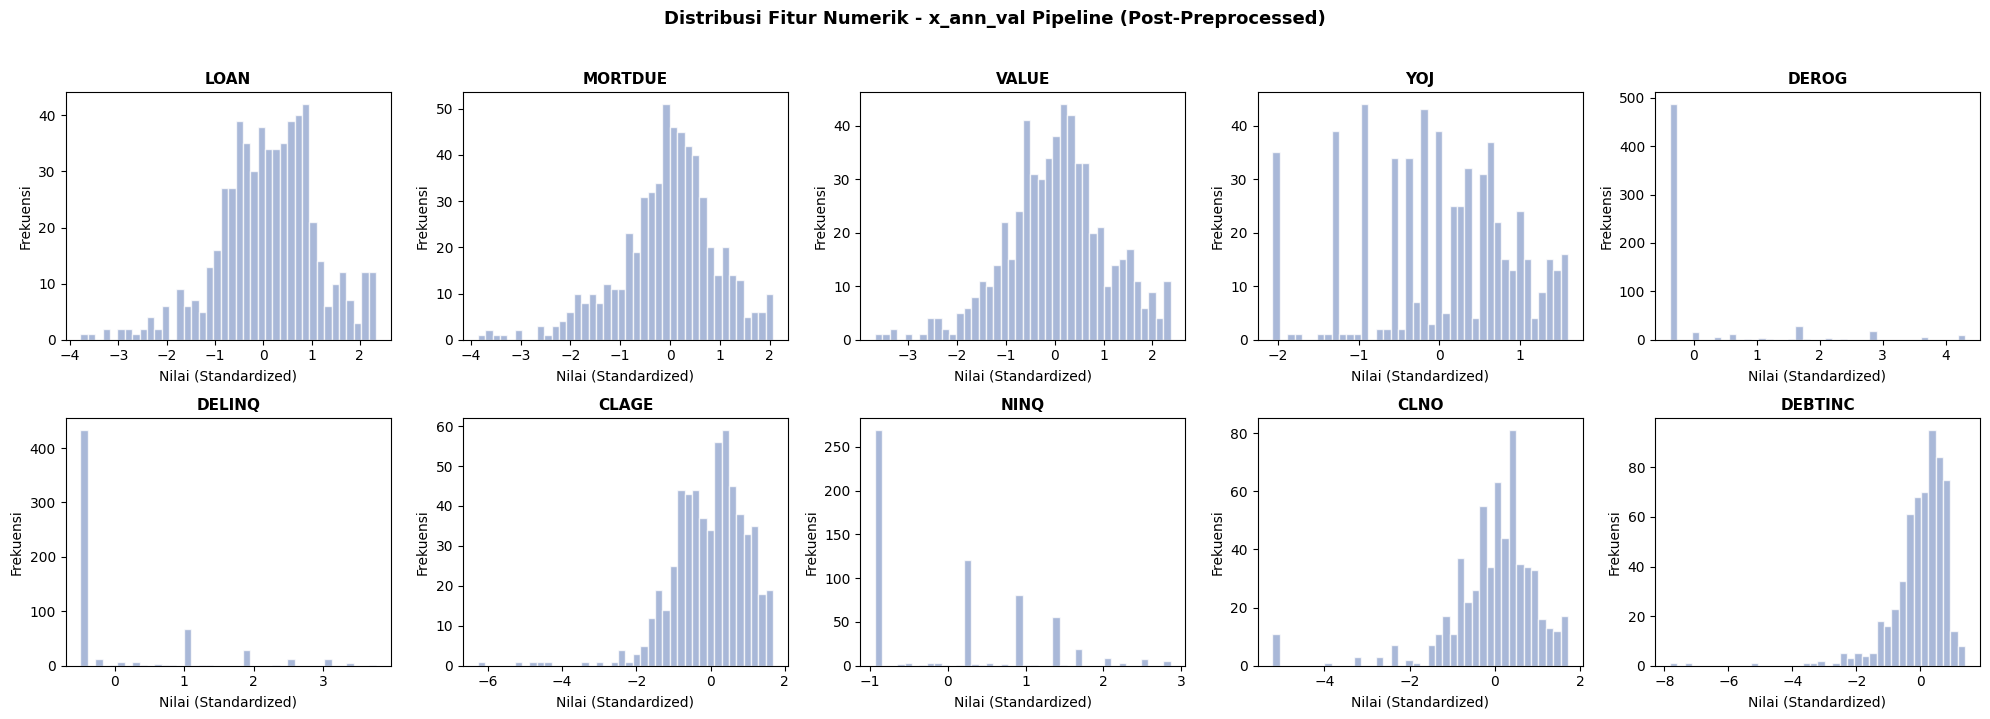


Memproses Grafik Distribusi untuk: x_ann_test


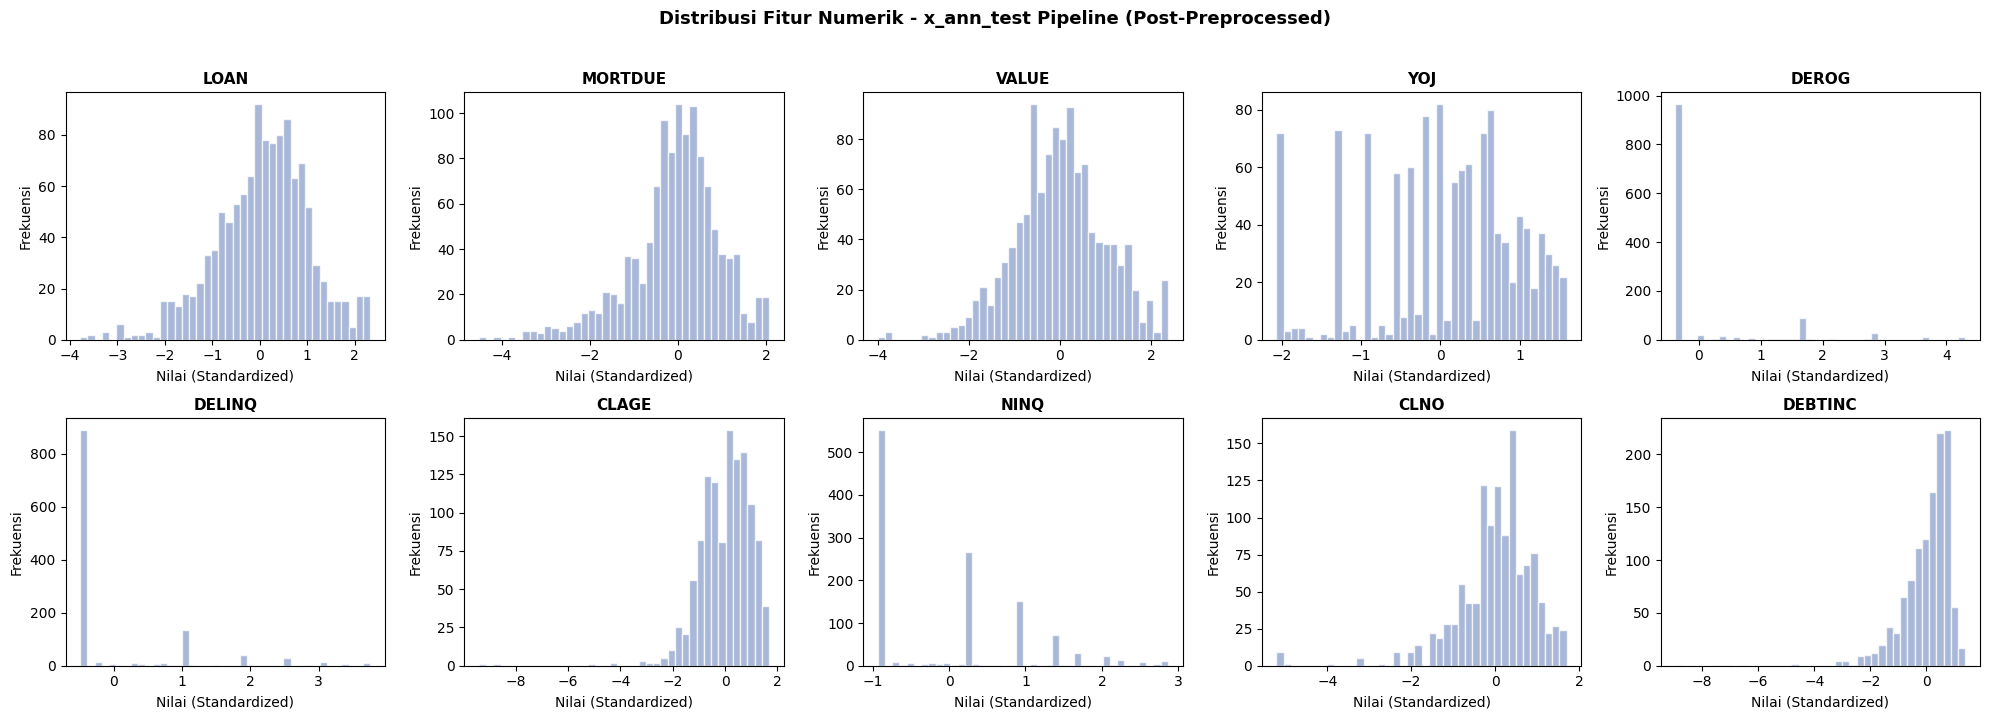


Dataset siap digunakan untuk analisis.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# cek palet warna seaborn
try:
    PALETTE
except NameError:
    PALETTE = sns.color_palette("Set2")

y = df_original['BAD'].values

lda_features = ['LOAN', 'VALUE', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'DEBTINC', 'JOB']
X_lda_raw = pd.get_dummies(df_original[lda_features].fillna({'JOB': 'Unknown'}), columns=['JOB'], drop_first=True)

ann_features = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'JOB', 'REASON']
X_ann_raw = pd.get_dummies(df_original[ann_features].fillna({'JOB': 'Unknown', 'REASON': 'Unknown'}), columns=['JOB', 'REASON'], drop_first=True)

# split dataset untuk LDA (Train:Test = 80:20)
x_lda_train, x_lda_test, y_lda_train, y_lda_test = train_test_split(
    X_lda_raw, y, test_size=0.20, random_state=42, stratify=y
)
x_lda_train, x_lda_test = x_lda_train.copy(), x_lda_test.copy()

# split dataset untuk ANN (Train:Validation:Test = 70:10:20)
X_ann_train_val, x_ann_test, y_ann_train_val, y_ann_test = train_test_split(
    X_ann_raw, y, test_size=0.20, random_state=42, stratify=y
)
x_ann_train, x_ann_val, y_ann_train, y_ann_val = train_test_split(
    X_ann_train_val, y_ann_train_val, test_size=0.125, random_state=42, stratify=y_ann_train_val
)
x_ann_train, x_ann_val, x_ann_test = x_ann_train.copy(), x_ann_val.copy(), x_ann_test.copy()

# visualisasi distribusi kelas target
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

def plot_stratified_count(y_data, ax, title_name):
    sns.countplot(x=y_data, ax=ax, palette=PALETTE[:2], hue=y_data, legend=False)
    s0 = sum(y_data == 0)
    s1 = sum(y_data == 1)
    proporsi_default = (s1 / (s0 + s1)) * 100
    ax.set_title(
        f'{title_name}\n'
        f'0 (Lunas): {s0} | 1 (Default): {s1}\n'
        f'Rasio Default: {proporsi_default:.2f}%',
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel("Status Target (BAD)")
    ax.set_ylabel("Jumlah Nasabah")

plot_stratified_count(y_lda_train, axes[0, 0], 'y_lda_train (Jalur Tradisional - 80%)')
plot_stratified_count(y_lda_test, axes[0, 1], 'y_lda_test (Jalur Tradisional - 20%)')
axes[0, 2].axis('off')
plot_stratified_count(y_ann_train, axes[1, 0], 'y_ann_train (Jalur Modern - 70%)')
plot_stratified_count(y_ann_val, axes[1, 1], 'y_ann_val (Jalur Modern - 10%)')
plot_stratified_count(y_ann_test, axes[1, 2], 'y_ann_test (Jalur Modern - 20%)')

plt.suptitle("Audit Kestabilan Stratifikasi Target BAD\nRasio Imbalance Terbukti Konsisten di Seluruh Komponen Split Data", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# isolasi fitur numerik agar kolom One Hot Encoding agar (dummy 0/1) tidak dilihat oleh pipeline
lda_num_cols = ['LOAN', 'VALUE', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'DEBTINC']
ann_num_cols = ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']

# preprocessing dataset LDA (berdasarkan kuantil dari TRAIN)
for col in lda_num_cols:
    x_lda_train[col] = np.log1p(x_lda_train[col])
    x_lda_test[col] = np.log1p(x_lda_test[col])

    cap_limit = x_lda_train[col].quantile(0.99)
    x_lda_train[col] = x_lda_train[col].clip(upper=cap_limit)
    x_lda_test[col] = x_lda_test[col].clip(upper=cap_limit)

# preprocessing dataset ANN (berdasarkan kuantil dari TRAIN)
for col in ann_num_cols:
    x_ann_train[col] = np.log1p(x_ann_train[col])
    x_ann_val[col] = np.log1p(x_ann_val[col])
    x_ann_test[col] = np.log1p(x_ann_test[col])

    cap_limit = x_ann_train[col].quantile(0.99)
    x_ann_train[col] = x_ann_train[col].clip(upper=cap_limit)
    x_ann_val[col] = x_ann_val[col].clip(upper=cap_limit)
    x_ann_test[col] = x_ann_test[col].clip(upper=cap_limit)


# Scaler LDA
scaler_lda = StandardScaler()
x_lda_train = pd.DataFrame(scaler_lda.fit_transform(x_lda_train), columns=x_lda_train.columns, index=x_lda_train.index)
x_lda_test = pd.DataFrame(scaler_lda.transform(x_lda_test), columns=x_lda_test.columns, index=x_lda_test.index)

# Scaler ANN
scaler_ann = StandardScaler()
x_ann_train = pd.DataFrame(scaler_ann.fit_transform(x_ann_train), columns=x_ann_train.columns, index=x_ann_train.index)
x_ann_val = pd.DataFrame(scaler_ann.transform(x_ann_val), columns=x_ann_val.columns, index=x_ann_val.index)
x_ann_test = pd.DataFrame(scaler_ann.transform(x_ann_test), columns=x_ann_test.columns, index=x_ann_test.index)

# Imputer LDA
imputer_lda = KNNImputer(n_neighbors=5)
x_lda_train = pd.DataFrame(imputer_lda.fit_transform(x_lda_train), columns=x_lda_train.columns, index=x_lda_train.index)
x_lda_test = pd.DataFrame(imputer_lda.transform(x_lda_test), columns=x_lda_test.columns, index=x_lda_test.index)

# Imputer ANN
imputer_ann = KNNImputer(n_neighbors=5)
x_ann_train = pd.DataFrame(imputer_ann.fit_transform(x_ann_train), columns=x_ann_train.columns, index=x_ann_train.index)
x_ann_val = pd.DataFrame(imputer_ann.transform(x_ann_val), columns=x_ann_val.columns, index=x_ann_val.index)
x_ann_test = pd.DataFrame(imputer_ann.transform(x_ann_test), columns=x_ann_test.columns, index=x_ann_test.index)

def check_missing_summary(df, name):
    print(f"\nPeta Missing Value di {name}:")
    summary = pd.DataFrame({
        "Missing": df.isnull().sum(),
        "Persentase (%)": (df.isnull().sum() / len(df) * 100).round(2)
    })
    summary = summary.sort_values("Persentase (%)", ascending=False)
    # tampilkan top 3 fitur dengan missing terbanyak (untuk membuktikan semuanya sudah 0)
    display(summary.head(3))

check_missing_summary(x_lda_train, "x_lda_train")
check_missing_summary(x_lda_test, "x_lda_test")
check_missing_summary(x_ann_train, "x_ann_train")
check_missing_summary(x_ann_val, "x_ann_val")
check_missing_summary(x_ann_test, "x_ann_test")

# visualisasi distribusi data setelah preprocessing
def plot_numerical_distributions(df, num_cols, color, dataset_name, nrows, ncols, figsize):
    print(f"\nMemproses Grafik Distribusi untuk: {dataset_name}")
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    for i, col in enumerate(num_cols):
        axes[i].hist(df[col], bins=40, color=color, alpha=0.75, edgecolor="white")
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("Nilai (Standardized)")
        axes[i].set_ylabel("Frekuensi")
    for j in range(len(num_cols), len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"Distribusi Fitur Numerik - {dataset_name} Pipeline (Post-Preprocessed)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_numerical_distributions(
    df=x_lda_train,
    num_cols=lda_num_cols,
    color=PALETTE[0],
    dataset_name="x_lda_train",
    nrows=2, ncols=4, figsize=(16, 7)
)

plot_numerical_distributions(
    df=x_lda_test,
    num_cols=lda_num_cols,
    color=PALETTE[0],
    dataset_name="x_lda_test",
    nrows=2, ncols=4, figsize=(16, 7)
)

plot_numerical_distributions(
    df=x_ann_train,
    num_cols=ann_num_cols,
    color=PALETTE[2],
    dataset_name="x_ann_train",
    nrows=2, ncols=5, figsize=(20, 7)
)

plot_numerical_distributions(
    df=x_ann_val,
    num_cols=ann_num_cols,
    color=PALETTE[2],
    dataset_name="x_ann_val",
    nrows=2, ncols=5, figsize=(20, 7)
)

plot_numerical_distributions(
    df=x_ann_test,
    num_cols=ann_num_cols,
    color=PALETTE[2],
    dataset_name="x_ann_test",
    nrows=2, ncols=5, figsize=(20, 7)
)

print("\nDataset siap digunakan untuk analisis.")

## **Pendekatan Klasik: LDA**

Run cell di bawah ini untuk membangun, melatih, dan mengevaluasi model *Machine Learning* tradisional berbasis Linear Discriminant Analysis (LDA) melalui skenario komparasi *head-to-head*:

1. Menginisialisasi dan melatih model LDA standar tanpa pembobotan per kelas sebagai *baseline* untuk melihat kecenderungan bias model terhadap kelas mayoritas.
2. Menginisialisasi model LDA tandingan dengan mengunci parameter prior probability secara seragam `priors=[0.5, 0.5]` untuk memaksa algoritma menggeser garis keputusan secara adil di tengah *class imbalance*.
3. Mengekstrak hasil prediksi keputusan biner beserta  skor probabilitas kelas positif (`BAD=1`) dari kedua variasi model pada *Test Set*.
4. Menyusun struktur iterasi evaluasi yang mengalkulasi 10 metrik performa lintas dimensi secara simultan, mulai dari akurasi secara umum, akurasi tertimbang, tingkat presisi, recall, variasi F1-Score (binary, macro, weighted), hingga evaluasi tingkat tinggi (dalam bentuk skor AUC-ROC, Cohen's Kappa, bahkan Matthew's Correlation Coefficient).
5. Memanfaatkan library `tabulate` untuk merangkum seluruh skor evaluasi serta menghitung nilai selisih (*gain/loss*) performa secara presisi dalam bentuk tabel bergaris yang rapi.
6. Mengonstruksi dua grafik *heatmap* Seaborn secara berdampingan antara model *Baseline* (palet hijau) dan *Balanced* (palet biru) untuk memuat **Confusion Matrix** dan meninjau angka alarm palsu (*False Positive*) dan kebocoran risiko (*False Negative*).
7. Mengintegrasikan lintasan kurva **Receiver Operating Characteristic** beserta nilai AUC dari kedua model ke dalam satu bidang koordinat untuk membandingkan kapasitas diskriminasi global secara transparan.

Eksperimen komparatif ini dirancang untuk membedah secara empiris **apakah intervensi matematis pada *prior probabilities* dapat memengaruhi sensitivitas deteksi risiko kredit macet** sekaligus menjadi *baseline* sebelum melakukan pendekatan modern.


╒════════════════════════════════════════╤══════════════════════════════╤═══════════════════════════════╤════════════════════╕
│ Metrik Evaluasi                        │   LDA Baseline (Tanpa Bobot) │   LDA Balanced (Dengan Bobot) │   Selisih Performa │
╞════════════════════════════════════════╪══════════════════════════════╪═══════════════════════════════╪════════════════════╡
│ Regular Accuracy                       │                       0.8154 │                        0.7701 │            -0.0453 │
├────────────────────────────────────────┼──────────────────────────────┼───────────────────────────────┼────────────────────┤
│ Balanced Accuracy                      │                       0.6308 │                        0.7035 │             0.0726 │
├────────────────────────────────────────┼──────────────────────────────┼───────────────────────────────┼────────────────────┤
│ Precision (Kelas 1 - Default)          │                       0.5662 │                        0.4434 │     

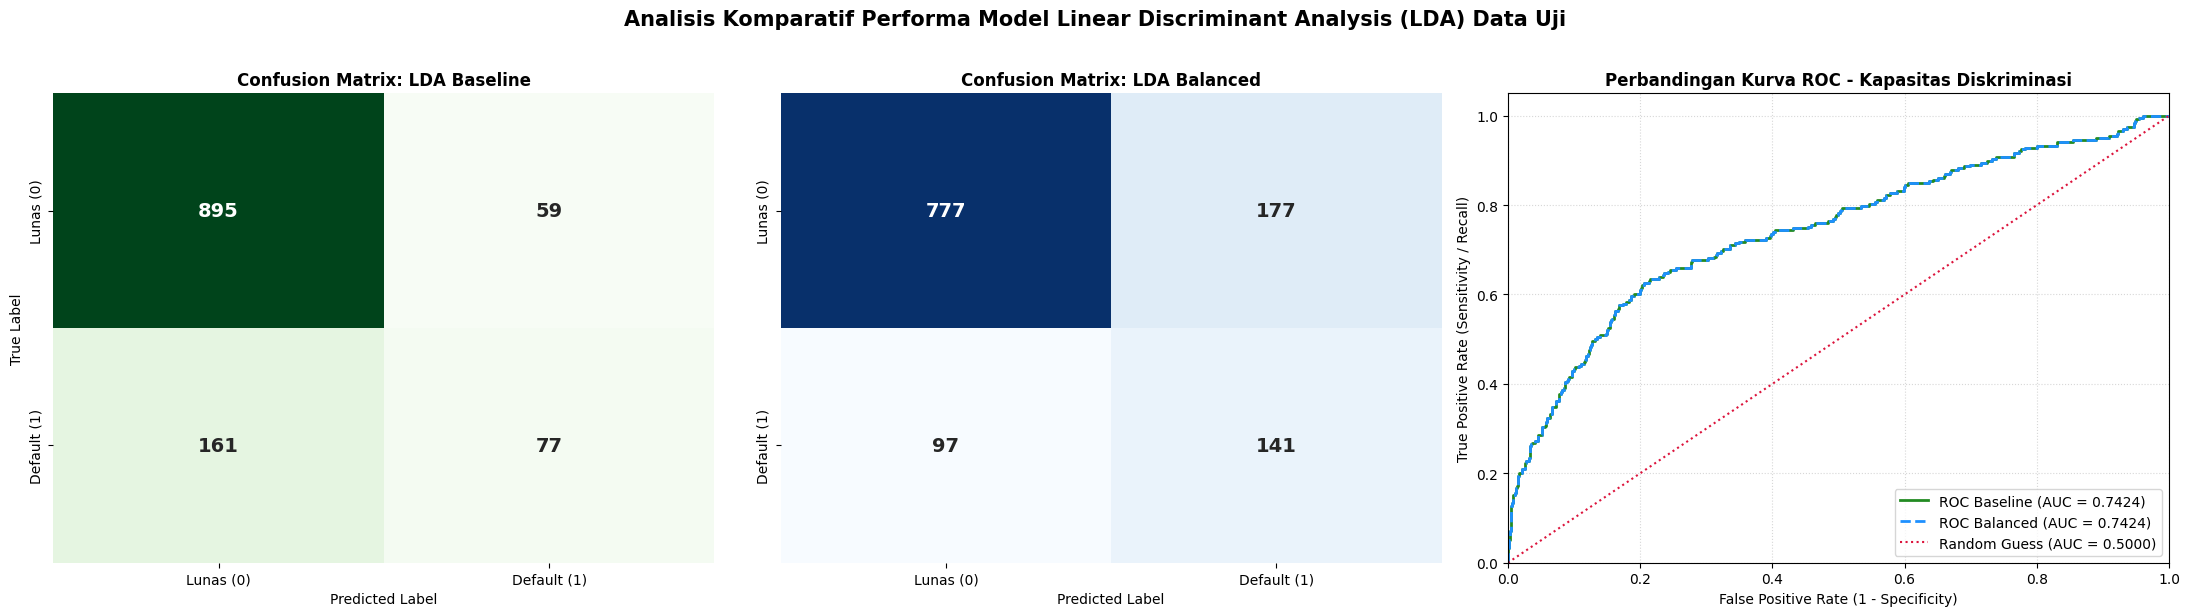

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, roc_curve, roc_auc_score,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.utils.class_weight import compute_sample_weight
from tabulate import tabulate

# Baseline (Tanpa Penyesuaian Bobot Kelas)
model_lda_base = LinearDiscriminantAnalysis()
model_lda_base.fit(x_lda_train, y_lda_train)
y_pred_base = model_lda_base.predict(x_lda_test)
y_prob_base = model_lda_base.predict_proba(x_lda_test)[:, 1]

# Balanced (Mengaktifkan Class Weight Berbasis Proporsi)
model_lda_weighted = LinearDiscriminantAnalysis(priors=[0.5, 0.5])
model_lda_weighted.fit(x_lda_train, y_lda_train)
y_pred_weighted = model_lda_weighted.predict(x_lda_test)
y_prob_weighted = model_lda_weighted.predict_proba(x_lda_test)[:, 1]

metrics_list = [
    ("Regular Accuracy", accuracy_score, "bin"),
    ("Balanced Accuracy", balanced_accuracy_score, "bin"),
    ("Precision (Kelas 1 - Default)", precision_score, "pos"),
    ("Recall / Sensitivity (Kelas 1)", recall_score, "pos"),
    ("F1-Score (Kelas 1 - Default)", f1_score, "pos"),
    ("F1-Score (Macro Average)", f1_score, "macro"),
    ("F1-Score (Weighted Average)", f1_score, "weighted"),
    ("ROC-AUC Score", roc_auc_score, "prob"),
    ("Matthews Correlation Coefficient (MCC)", matthews_corrcoef, "bin"),
    ("Cohen's Kappa Score", cohen_kappa_score, "bin")
]

table_data = []

for name, metric_func, type_cal in metrics_list:
    if type_cal == "bin":
        score_base = metric_func(y_lda_test, y_pred_base)
        score_weight = metric_func(y_lda_test, y_pred_weighted)
    elif type_cal == "pos":
        score_base = metric_func(y_lda_test, y_pred_base, pos_label=1)
        score_weight = metric_func(y_lda_test, y_pred_weighted, pos_label=1)
    elif type_cal == "macro":
        score_base = metric_func(y_lda_test, y_pred_base, average='macro')
        score_weight = metric_func(y_lda_test, y_pred_weighted, average='macro')
    elif type_cal == "weighted":
        score_base = metric_func(y_lda_test, y_pred_base, average='weighted')
        score_weight = metric_func(y_lda_test, y_pred_weighted, average='weighted')
    elif type_cal == "prob":
        score_base = metric_func(y_lda_test, y_prob_base)
        score_weight = metric_func(y_lda_test, y_prob_weighted)

    diff = score_weight - score_base
    table_data.append([name, f"{score_base:.4f}", f"{score_weight:.4f}", f"{diff:+.4f}"])

headers = ["Metrik Evaluasi", "LDA Baseline (Tanpa Bobot)", "LDA Balanced (Dengan Bobot)", "Selisih Performa"]
print("\n" + tabulate(table_data, headers=headers, tablefmt="fancy_grid") + "\n")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Confusion Matrix - Baseline
cm_base = confusion_matrix(y_lda_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Confusion Matrix: LDA Baseline", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Lunas (0)', 'Default (1)'])
axes[0].set_yticklabels(['Lunas (0)', 'Default (1)'])
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Confusion Matrix - Balanced
cm_weighted = confusion_matrix(y_lda_test, y_pred_weighted)
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("Confusion Matrix: LDA Balanced", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Lunas (0)', 'Default (1)'])
axes[1].set_yticklabels(['Lunas (0)', 'Default (1)'])
axes[1].set_xlabel("Predicted Label")

# Overlapping Kurva ROC
fpr_base, tpr_base, _ = roc_curve(y_lda_test, y_prob_base)
fpr_weight, tpr_weight, _ = roc_curve(y_lda_test, y_prob_weighted)

auc_base = roc_auc_score(y_lda_test, y_prob_base)
auc_weight = roc_auc_score(y_lda_test, y_prob_weighted)

axes[2].plot(fpr_base, tpr_base, color='forestgreen', lw=2, linestyle='-', label=f'ROC Baseline (AUC = {auc_base:.4f})')
axes[2].plot(fpr_weight, tpr_weight, color='dodgerblue', lw=2, linestyle='--', label=f'ROC Balanced (AUC = {auc_weight:.4f})')
axes[2].plot([0, 1], [0, 1], color='crimson', lw=1.5, linestyle=':', label='Random Guess (AUC = 0.5000)')

axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate (1 - Specificity)')
axes[2].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[2].set_title('Perbandingan Kurva ROC - Kapasitas Diskriminasi', fontsize=12, fontweight='bold')
axes[2].legend(loc="lower right")
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Analisis Komparatif Performa Model Linear Discriminant Analysis (LDA) Data Uji", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Analisis Hasil LDA**

Berdasarkan hasil pengujian model *Linear Discriminant Analysis* (LDA), diperoleh perbandingan performa yang kontras namun sangat logis antara varian **LDA Baseline** (tanpa pembobotan) dan **LDA Balanced** (dengan bobot proporsi `priors=[0.5, 0.5]`).

**1. Fenomena Nilai ROC-AUC yang Identik (0.7425)**

Satu hal yang sangat menarik dari visualisasi kurva ROC adalah nilai **ROC-AUC Score yang sama persis di angka 0.7425** (tanpa selisih) dan menunjukkan bahwaintervensi pemberian bobot kelas prior pada LDA **tidak mengubah kapasitas dasar model dalam  membedakan fitur-fitur** ketika memisahkan kelas nasabah Lunas (0) dan Default (1). Pemberian bobot hanya bertindak menggeser posisi batas keputusan (*decision boundary*) di sepanjang kurva ROC yang sama sehingga memicu terjadinya perubahan pada metrik klasifikasi biner lainnya seperti *Accuracy, Precision,* dan *Recall*.

**2. Efek Pergeseran Batas Keputusan pada Confusion Matrix**

Perubahan posisi batas keputusan terlihat sangat jelas saat kita membedah persebaran angka pada *Confusion Matrix*:

* **LDA Baseline (Main Aman):** Model ini menghasilkan True Negative (TN) yang sangat tinggi yaitu **895** namun gagal menangkap mayoritas nasabah kredit macet dengan True Positive (TP) yaitu hanya sebanyak **77** dan menghasilkan False Negative (FN) yang membengkak di angka **161**. Model baseline  bias ke kelas mayoritas karena distribusinya jomplang (81% aman dan 19% default).
* **LDA Balanced (Lebih Sensitif):** Ketika prior dipaksa menjadi seimbang (50:50) maka model menjadi jauh lebih sensitif di mana nilai TP naik menjadi **142** (hampir dua kali lipat) dan angka FN berhasil ditekan turun drastis dari 161 menjadi **96** namun kompensasinya adalah model menjadi lebih paranoid sehingga False Positive (FP) ikut naik dari 59 menjadi **178**.

**Keunggulan LDA Balanced Berdasarkan Metrik MCC dan F1-Score**

Meskipun *Regular Accuracy* pada LDA Balanced mengalami penurunan sebesar **-0.0453** (dari 81.54% menjadi 77.01%), penurunan ini dapat dianggap sebagai *false alarm* karena sifat akurasi reguler yang bias pada *imbalanced data*. Berikut adalah bukti bahwa model yang Balanced dapat dikatakan jauh lebih berkualitas:

* **Lonjakan Recall (+27.31%):** Kemampuan model dalam mendeteksi nasabah yang berisiko gagal bayar (Default) melonjak tajam dari **32.35% ke 59.66%** di mana kenaikan ini sangat krusial untuk menghindari kerugian akibat salah meloloskan debitur macet.
* **Kenaikan F1-Score Kelas 1 (+0.0972):** Nilai F1-score khusus kelas default naik dari **0.4118 ke 0.5090** sehingga  menandakan bahwa keseimbangan antara *Precision* dan *Recall* baru yang terbentuk jauh lebih optimal daripada baselinenya.
* **Peningkatan Nilai MCC (+0.0409):** Matthews Correlation Coefficient (MCC) merangkak naik dari **0.3290 ke 0.3699** dan begitu juga dengan Cohen's Kappa yang naik menjadi **0.3631** sehingga kenaikan kedua metrik ini menegaskan bahwa model LDA Balanced memiliki kualitas klasifikasi biner yang lebih stabil dan objektif.

## **Pendekatan Modern: ANN**

Run cell di bawah ini untuk membangun, melatih, dan mengevaluasi model *Deep Learning* modern berbasis *Artificial Neural Network* (ANN) melalui skenario komparasi *head-to-head*:

1. Mengeksekusi `tf.config.experimental.enable_op_determinism()` serta mengunci `random_seed=42` pada TensorFlow dan NumPy untuk menjamin sirkuit paralel GPU menghasilkan kalkulasi matriks yang konsisten dan dapat direproduksi setiap *running*.
2. Membangun ANN melalui fungsi `build_ann` berbasis model sekuensial yang terdiri dari tiga *hidden layer* teroptimasi (128, 64, dan 32 neuron) di mana setiap lapisan diintegrasikan dengan `BatchNormalization` sebelum aktivasi untuk mempercepat konvergensi barulah digunakan fungsi aktivasi `swish` untuk memetakan hubungan fitur yang kompleks serta regularisasi `Dropout` (0.15, 0.10, 0.05) untuk mencegah *overfitting*.
3. Mengonfigurasikan fungsionalitas pelatihan menggunakan optimizer **AdamW** dengan `weight_decay=1e-4` yang memisahkan fungsi penalti berat dari momen gradien untuk mempertahankan *Precision* dan dipadukan dengan loss function *Binary Crossentropy*.
4. Sebelumnya telah dicari hyperparameter sebanyak beberapa kali percobaan dan berakhir menggunakan`batch_size=256` untuk maksimal 300 *epochs* pada model pertama tanpa pembobotan (baseline). Proses pelatihan dikendalikan oleh `EarlyStopping` (dengan kesabaran 50 epoch untuk memantau `val_loss` di mana training harus dihentikan ketika tidak menemukan `val_loss` terbaik setelah 50 epoch dari yang terbaik sebelumnya) dan `ReduceLROnPlateau` yang otomatis membagi dua *learning rate* jika grafik evaluasi mengalami stagnasi (*plateau*).
5. Melatih model tandingan menggunakan parameter arsitektur yang sama persis, namun menyuntikkan intervensi penalti *Weighted Crossentropy* melalui kamus bobot kelas `class_weight_dict = {0: 1.0, 1: 2.2}` guna memaksa neural network memberi perhatian lebih pada kelas *Default* sebagai kelas minoritas.
6. Mengekstrak probabilitas kontinu dari lapisan output `sigmoid` pada *Test Set*, lalu dikonversi menjadi keputusan biner melalui  **`decision_threshold = 0.40`** untuk menggeser sensitivitas model untuk hasil akhir prediksinya.
7. Membuat dua kurva interaktif secara berdampingan untuk melacak pergerakan nilai `Train Loss` dan `Val Loss` di setiap lintasan epoch guna mendeteksi secara dini tanda-tanda jenuh atau *overfitting* pada kedua variasi model ANN.
8. Memanfaatkan skrip otomatis untuk menghitung 10 metrik performa yang digunakan juga pada pendekatan klasik dengan LDA yaitu akurasi secara umum, akurasi tertimbang, tingkat presisi, recall, variasi F1-Score (binary, macro, weighted), hingga evaluasi tingkat tinggi (dalam bentuk skor AUC-ROC, Cohen's Kappa, bahkan Matthew's Correlation Coefficient).
9. Membuka visualisasi komparatif tiga panel yang memuat dua *heatmap* Seaborn untuk **Confusion Matrix** (palet hijau untuk Baseline dan palet biru untuk Balanced) untuk menghitung persebaran distribusi angka *False Positive* dan *False Negative* secara nyata serta sebuah kurva **Receiver Operating Characteristic (ROC)** yang tumpang-tindih beserta nilai AUC dari kedua model ANN untuk mengukur keandalan model dalam klasifikasi biner terlepas dari manipulasi ambang batas keputusan.

Eksperimen komparatif ini dirancang untuk membedah secara empiris **sejauh mana kapasitas arsitektur non-linear melalui ANN mampu melompati batasan linear model klasik yaitu LDA**. Eksperimen ini juga berupaya untuk melihat apakah `class_weight` dan *Threshold Tuning* efektif dalam meningkatkan performa klasifikasi dataset HMEQ yang mengalami *class imbalance*.


Memulai Pelatihan Model ANN Baseline...
Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6944 - auc: 0.7535 - loss: 0.6095 - recall: 0.6803 - val_accuracy: 0.7718 - val_auc: 0.8106 - val_loss: 0.6148 - val_recall: 0.7059 - learning_rate: 0.0020
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8058 - auc: 0.8255 - loss: 0.4776 - recall: 0.6214 - val_accuracy: 0.8238 - val_auc: 0.8233 - val_loss: 0.5527 - val_recall: 0.5546 - learning_rate: 0.0020
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8452 - auc: 0.8427 - loss: 0.4054 - recall: 0.5337 - val_accuracy: 0.8440 - val_auc: 0.8348 - val_loss: 0.4948 - val_recall: 0.4622 - learning_rate: 0.0020
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8526 - auc: 0.8475 - loss: 0.3705 - recall: 0.5144 - val_accuracy: 0.8540 - val_auc: 0.8470 - val_loss: 0.4429 - val_recall: 0.3950 - learning_rate: 0.0020
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8634 

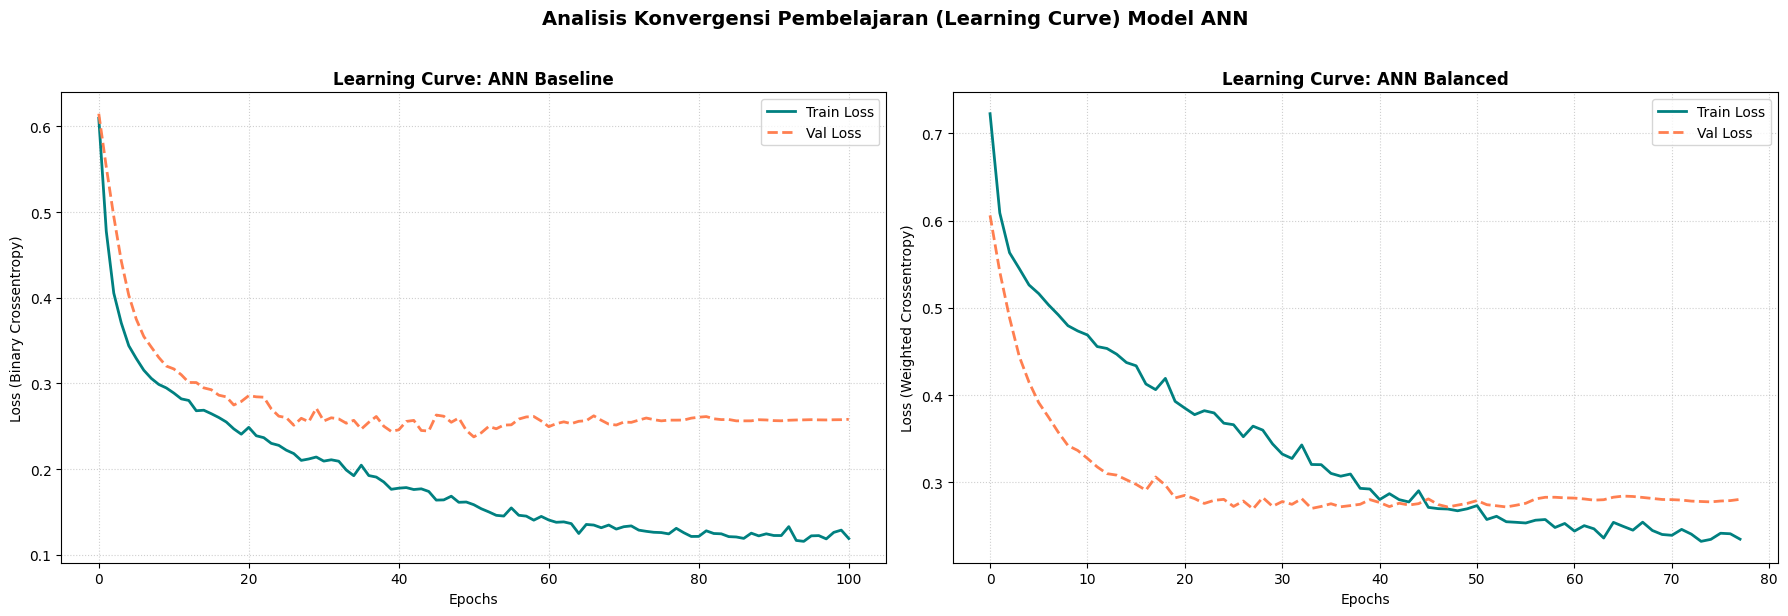


╒════════════════════════════════════════╤══════════════════════════════╤═══════════════════════════════╤════════════════════╕
│ Metrik Evaluasi                        │   ANN Baseline (Tanpa Bobot) │   ANN Balanced (Dengan Bobot) │   Selisih Performa │
╞════════════════════════════════════════╪══════════════════════════════╪═══════════════════════════════╪════════════════════╡
│ Regular Accuracy                       │                       0.9094 │                        0.8893 │            -0.0201 │
├────────────────────────────────────────┼──────────────────────────────┼───────────────────────────────┼────────────────────┤
│ Balanced Accuracy                      │                       0.7999 │                        0.7921 │            -0.0078 │
├────────────────────────────────────────┼──────────────────────────────┼───────────────────────────────┼────────────────────┤
│ Precision (Kelas 1 - Default)          │                       0.8963 │                        0.7732 │     

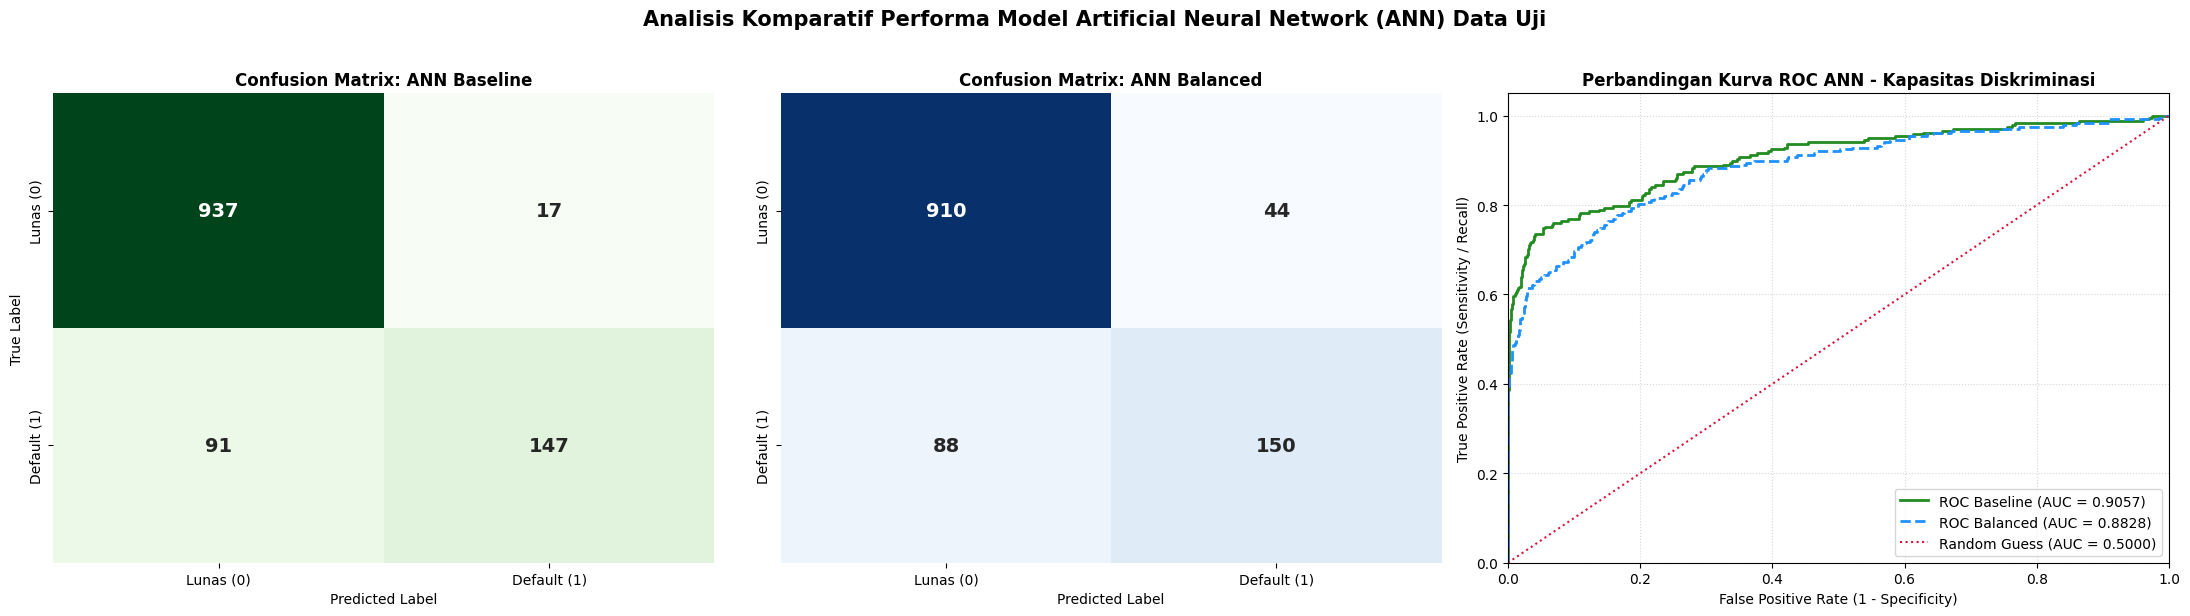

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, balanced_accuracy_score, roc_curve, roc_auc_score,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.utils.class_weight import compute_class_weight
from tabulate import tabulate

tf.config.experimental.enable_op_determinism()
tf.random.set_seed(42)
np.random.seed(42)

decision_threshold = 0.40

def build_ann(input_dim, lr_rate=0.001):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(128, activation=None),
        BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        Dropout(0.15),

        Dense(64, activation=None),
        BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        Dropout(0.1),

        Dense(32, activation=None),
        BatchNormalization(),
        tf.keras.layers.Activation('swish'),
        Dropout(0.05),

        Dense(1, activation='sigmoid')
    ])

    opt = tf.keras.optimizers.AdamW(learning_rate=lr_rate, weight_decay=1e-4)
    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
    )
    return model

input_shape = x_ann_train.shape[1]

early_stop_base = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
reduce_lr_base = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

# ANN Baseline (Tanpa Intervensi Bobot Kelas)
print("\nMemulai Pelatihan Model ANN Baseline...")
model_ann_base = build_ann(input_shape, lr_rate=0.002)
history_base = model_ann_base.fit(
    x_ann_train, y_ann_train,
    validation_data=(x_ann_val, y_ann_val),
    epochs=300,
    batch_size=256,
    callbacks=[early_stop_base, reduce_lr_base],
    verbose=1
)
y_prob_ann_base = model_ann_base.predict(x_ann_test, verbose=1).flatten()
y_pred_ann_base = (y_prob_ann_base >= decision_threshold).astype(int)

early_stop_weighted = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True, verbose=1)
reduce_lr_weighted = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)

# ANN Balanced (Intervensi Dictionary Class Weights)
print("Memulai Pelatihan Model ANN Balanced...")
classes = np.unique(y_ann_train)
class_weight_dict = {0: 1.0, 1: 2.2} # sesuai proporsi 19.97% di preprocessing

model_ann_weighted = build_ann(input_shape, lr_rate=0.002)
history_weighted = model_ann_weighted.fit(
    x_ann_train, y_ann_train,
    validation_data=(x_ann_val, y_ann_val),
    epochs=300,
    batch_size=256,
    callbacks=[early_stop_weighted, reduce_lr_weighted],
    class_weight=class_weight_dict,
    verbose=1
)
y_prob_ann_weighted = model_ann_weighted.predict(x_ann_test, verbose=1).flatten()
y_pred_ann_weighted = (y_prob_ann_weighted >= decision_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Learning Curve ANN Baseline
axes[0].plot(history_base.history['loss'], label='Train Loss', color='teal', lw=2)
axes[0].plot(history_base.history['val_loss'], label='Val Loss', color='coral', lw=2, linestyle='--')
axes[0].set_title('Learning Curve: ANN Baseline', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Binary Crossentropy)')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Learning Curve ANN Balanced
axes[1].plot(history_weighted.history['loss'], label='Train Loss', color='teal', lw=2)
axes[1].plot(history_weighted.history['val_loss'], label='Val Loss', color='coral', lw=2, linestyle='--')
axes[1].set_title('Learning Curve: ANN Balanced', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (Weighted Crossentropy)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Analisis Konvergensi Pembelajaran (Learning Curve) Model ANN", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

metrics_list = [
    ("Regular Accuracy", accuracy_score, "bin"),
    ("Balanced Accuracy", balanced_accuracy_score, "bin"),
    ("Precision (Kelas 1 - Default)", precision_score, "pos"),
    ("Recall / Sensitivity (Kelas 1)", recall_score, "pos"),
    ("F1-Score (Kelas 1 - Default)", f1_score, "pos"),
    ("F1-Score (Macro Average)", f1_score, "macro"),
    ("F1-Score (Weighted Average)", f1_score, "weighted"),
    ("ROC-AUC Score", roc_auc_score, "prob"),
    ("Matthews Correlation Coefficient (MCC)", matthews_corrcoef, "bin"),
    ("Cohen's Kappa Score", cohen_kappa_score, "bin")
]

table_data = []

for name, metric_func, type_cal in metrics_list:
    if type_cal == "bin":
        score_base = metric_func(y_ann_test, y_pred_ann_base)
        score_weight = metric_func(y_ann_test, y_pred_ann_weighted)
    elif type_cal == "pos":
        score_base = metric_func(y_ann_test, y_pred_ann_base, pos_label=1)
        score_weight = metric_func(y_ann_test, y_pred_ann_weighted, pos_label=1)
    elif type_cal == "macro":
        score_base = metric_func(y_ann_test, y_pred_ann_base, average='macro')
        score_weight = metric_func(y_ann_test, y_pred_ann_weighted, average='macro')
    elif type_cal == "weighted":
        score_base = metric_func(y_ann_test, y_pred_ann_base, average='weighted')
        score_weight = metric_func(y_ann_test, y_pred_ann_weighted, average='weighted')
    elif type_cal == "prob":
        score_base = metric_func(y_ann_test, y_prob_ann_base)
        score_weight = metric_func(y_ann_test, y_prob_ann_weighted)

    diff = score_weight - score_base
    table_data.append([name, f"{score_base:.4f}", f"{score_weight:.4f}", f"{diff:+.4f}"])

headers = ["Metrik Evaluasi", "ANN Baseline (Tanpa Bobot)", "ANN Balanced (Dengan Bobot)", "Selisih Performa"]
print("\n" + tabulate(table_data, headers=headers, tablefmt="fancy_grid") + "\n")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Confusion Matrix - ANN Baseline
cm_ann_base = confusion_matrix(y_ann_test, y_pred_ann_base)
sns.heatmap(cm_ann_base, annot=True, fmt='d', cmap='Greens', ax=axes[0], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Confusion Matrix: ANN Baseline", fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Lunas (0)', 'Default (1)'])
axes[0].set_yticklabels(['Lunas (0)', 'Default (1)'])
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Confusion Matrix - ANN Balanced
cm_ann_weighted = confusion_matrix(y_ann_test, y_pred_ann_weighted)
sns.heatmap(cm_ann_weighted, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("Confusion Matrix: ANN Balanced", fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Lunas (0)', 'Default (1)'])
axes[1].set_yticklabels(['Lunas (0)', 'Default (1)'])
axes[1].set_xlabel("Predicted Label")

# Overlapping Kurva ROC
fpr_ann_base, tpr_ann_base, _ = roc_curve(y_ann_test, y_prob_ann_base)
fpr_ann_weight, tpr_ann_weight, _ = roc_curve(y_ann_test, y_prob_ann_weighted)

auc_ann_base = roc_auc_score(y_ann_test, y_prob_ann_base)
auc_ann_weight = roc_auc_score(y_ann_test, y_prob_ann_weighted)

axes[2].plot(fpr_ann_base, tpr_ann_base, color='forestgreen', lw=2, linestyle='-', label=f'ROC Baseline (AUC = {auc_ann_base:.4f})')
axes[2].plot(fpr_ann_weight, tpr_ann_weight, color='dodgerblue', lw=2, linestyle='--', label=f'ROC Balanced (AUC = {auc_ann_weight:.4f})')
axes[2].plot([0, 1], [0, 1], color='crimson', lw=1.5, linestyle=':', label='Random Guess (AUC = 0.5000)')

axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate (1 - Specificity)')
axes[2].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[2].set_title('Perbandingan Kurva ROC ANN - Kapasitas Diskriminasi', fontsize=12, fontweight='bold')
axes[2].legend(loc="lower right")
axes[2].grid(True, linestyle=':', alpha=0.5)

plt.suptitle("Analisis Komparatif Performa Model Artificial Neural Network (ANN) Data Uji", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# simpan best model
model_ann_base.save('best_ann_baseline_mcc69.keras')
model_ann_weighted.save('best_ann_weighted_mcc63.keras')

from google.colab import files
files.download('best_ann_baseline_mcc69.keras')
files.download('best_ann_weighted_mcc63.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Analisis Hasil ANN**

Berdasarkan visualisasi *confusion matrix*, kurva *Receiver Operating Characteristic*, dan *learning curve* maka dapat disimpulkan bahwa penggunaan *Artificial Neural Network* (ANN) berhasil mencapai *peak performance* dalam klasifikasi risiko kredit pada dataset HMEQ.

**1. ANN Baseline Lebih Baik Daripada ANN Balanced**

Berbeda dengan pengujian pada LDA, arsitektur *Deep Learning* **ANN Baseline (Tanpa Bobot)** adalah yang terbaik di studi kasus ini karena mengalahkan versi *Balanced*-nya sekalipun selisihnya tidak berbeda jauh.

* Nilai Matthews Correlation Coefficient (MCC) sebesar **0.6961** (mendekati 0.70) mengindikasikan kekuatan asosiasi klasifikasi biner yang kuat dan stabil di kedua kelas target.
* Nilai AUC yang berhasil menembus  **0.90** membuktikan bahwa arsitektur ANN yang dirancang memiliki kapasitas diskriminasi yang  tangguh dalam memisahkan probabilitas nasabah aman dan nasabah gagal bayar (*default*).
* Hasil ini membuktikan secara empiris bahwa ketika arsitektur ANN dikombinasikan dengan optimasi batas keputusan *Threshold Tuning* maka **model mampu mengekstrak representasi fitur non-linear secara mandiri tanpa memerlukan intervensi pembobotan *loss function* di `class_weight`.** Intervensi bobot pada ANN Balanced justru memicu sedikit disorientasi pada peta gradien sehingga menurunkan nilai MCC menjadi 0.6326 dan ROC-AUC menjadi 0.8828.

**2. Analisis Distribusi Klasifikasi Berdasarkan Confusion Matrix**

Evaluasi berbasis jumlah sampel riil pada *Confusion Matrix* menunjukkan efisiensi alokasi prediksi yang menguntungkan:

* **ANN Baseline:** Dari total data uji, model ini berhasil menebak **937** nasabah Lunas secara presisi (True Negative) dan hanya melakukan salah tuduh (*false alarm*) sebanyak **17** nasabah. Nilai **Precision Kelas 1 berhasil meroket hingga 89.63%** yang jika dilihat dari kacamata bisnis perbankan akan sangat aman karena bank tidak kehilangan potensi keuntungan dari nasabah yang sebenarnya potensial akibat kesalahan deteksi dari sistem.
* **ANN Balanced:** Meskipun versi *Balanced* berhasil menangkap 3 nasabah macet lebih banyak (True Positive = 150 vs 147) sehingga nilai *Recall* naik tipis sebesar **+1.26%**, kompensasi kerugiannya terlalu mahal karena *False Positive*-nya membengkak jadi **44** nasabah (naik lebih dari dua kali lipat) dan secara langsung menurunkan *Precision*  ke angka **77.32% (-12.31%)**.

**3. Analisis Stabilitas Konvergensi Berdasarkan Learning Curve**

*Learning Curve* memberikan konfirmasi visual bahwa proses pelatihan model berjalan di atas jalur deterministik yang sehat:

* Kedua grafik menunjukkan pergerakan kurva `Train Loss` dan `Val Loss` yang meluncur turun secara monoton dan halus (*smooth*) sebagai akibat dari kelancaran distribusi gradien melalui lapisan `BatchNormalization` dan fungsi aktivasi `swish`.
* Pada ANN Baseline, proses pelatihan memanfaatkan *patience* secara maksimal hingga menyentuh Epoch 100. Kurva `Val Loss` menetap secara konstan di area *plateau* bawah (~0.25) tanpa menunjukkan gejala divergensi di kurva validasi sehingga mekanisme `ReduceLROnPlateau` berhasil mengecilkan *learning rate* secara presisi terhadap waktu di *global minima*.

# **Integration Analysis**

Tahap *Integration Analysis* dirancang sebagai fondasi evaluasi sistematis untuk menguji tingkat keselarasan, konsistensi, dan kaitan keputusan antara hasil pengelompokan alami (*unsupervised clustering*), prediksi model klasifikasi (*supervised learning*), dan realitas aktual (*ground truth*) yang pendekatannya terbagi menjadi dua metode berikut yang saling melengkapi:

* **Validasi Geometris terhadap Realitas Data (External Cluster Validation):** Berfokus pada pengujian awal untuk membuktikan apakah struktur kluster K-Means yang terbentuk murni berdasarkan jarak spasial data memiliki relevansi nyata terhadap pemetaan risiko kredit. Kluster alami akan dikonversi menjadi label biner berdasarkan *profiling* karakteristik finansial untuk meninjau sensitivitas model *unsupervised* dalam meredam efek *class imbalance*. dan disandingkan terhadap label aktualnya sebagai ground truth.
* **Triangulasi Sudut Pandang Lintas Paradigma (Triangulasi Paradigma):** Berfokus pada pengujian keandalan tingkat tinggi dengan memperlakukan *Ground Truth*, *ANN Baseline*, *LDA Balanced*, dan *K-Means Mapped* sebagai empat penilai (*rater*) independen dalam matriks grid 4x4 penuh dan merepresentasikan masing-masing pendekatan dengan performa terbaik. Metode ini secara ketat memanfaatkan metrik kesepakatan *Cohen's Kappa* untuk mengukur keandalan keselarasan antar-model secara adil tanpa adanya bias klasifikasi dari salah satu pihak.

Melalui kedua metode besar di atas, karakteristik masing-masing paradigma baik secara kedalaman non-linear di ANN, batasan linear klasik di LDA, maupun partisi spasial ruang Euclidean di K-Means dapat diaudit secara holistik untuk memberikan gambaran komprehensif terkait sintesis insight yang diperoleh dari analisis dataset HMEQ beserta dengan kesimpulan besarnya.

## **External Cluster Validation**

Run cell di bawah ini untuk melakukan evaluasi validasi eksternal pada hasil pengelompokan alami (*unsupervised*) dengan algoritma k-means terhadap label aktual (*ground truth*):

1. Ambil label target aktual (`BAD`) dan kluster-nya (`Cluster_Risiko`) secara langsung untuk disandingkan secara berpasangan.
2. Buat matriks kontingensi (*cross-tabulation*) untuk mengamati sebaran sampel nyata dan menghitung persentase nasabah secara horizontal untuk tiap kluster.
3. Hitung metrik validasi tingkat tinggi berupa *Adjusted Rand Index* (ARI) dan *Normalized Mutual Information* (NMI) untuk mengukur kesamaan pasangan kelompok spasial dan kekayaan informasi sebelum intervensi pemetaan.
4. Pemetaan manual (*manual override mapping* dengan konfigurasi `{0: 0, 1: 1}`) berdasarkan hasil *profiling* karakteristik finansial untuk meredam dampak bias *class imbalance*.
5. Ekstraksi metrik keselarasan klasifikasi natural (*Accuracy*, *Precision*, *Recall*, dan *F1-Score*) post-mapping label untuk menguji kualitas kluster dalam menjaring kelompok nasabah berisiko tinggi.
6. Hitung kekuatan asosiasi melalui *Matthews Correlation Coefficient* (MCC) dan tingkat kesepakatan *Cohen's Kappa* untuk mengeliminasi faktor kebetulan (*chance agreement*) pada performa penilaian inter-rater.
7. Tabulasi ringkasan kontingensi, persentase kemurnian, dan metrik evaluasi menggunakan `tabulate` dengan grid yang rapi.
8. Render visualisasi terintegrasi menggunakan Seaborn dan Matplotlib yang menggabungkan *heatmap* kontingensi dengan *stacked bar* untuk meninjau visualisasi tingkat kemurnian kluster (*cluster purity*).

Kerangka evaluasi ini dirancang untuk menggambarkan performa pengelompokan geometris k-means dan bertindak sebagai validator eksternal apakah pola finansial nasabah *default* membentuk struktur kelompok yang nyata secara spasial.


Tabel Silang Kontingensi (Frekuensi Sampel):
╒═══════════╤════════════╤═══════════════╕
│           │   Aman (0) │   Default (1) │
╞═══════════╪════════════╪═══════════════╡
│ Cluster 0 │       4072 │           597 │
├───────────┼────────────┼───────────────┤
│ Cluster 1 │        699 │           592 │
╘═══════════╧════════════╧═══════════════╛

Tabel Silang Proporsi Per Kluster (Horizontal %):
╒═══════════╤════════════╤═══════════════╕
│           │ Aman (0)   │ Default (1)   │
╞═══════════╪════════════╪═══════════════╡
│ Cluster 0 │ 87.21%     │ 12.79%        │
├───────────┼────────────┼───────────────┤
│ Cluster 1 │ 54.14%     │ 45.86%        │
╘═══════════╧════════════╧═══════════════╛

Metrik Evaluasi Validasi Eksternal Kluster:
╒════════════════════════════════════════╤═════════════════╤═════════════════════════════════════════════════════════╕
│ Metrik Validasi Eksternal              │   Skor Performa │ Interpretasi Teoretis                                   │
╞═════════════════

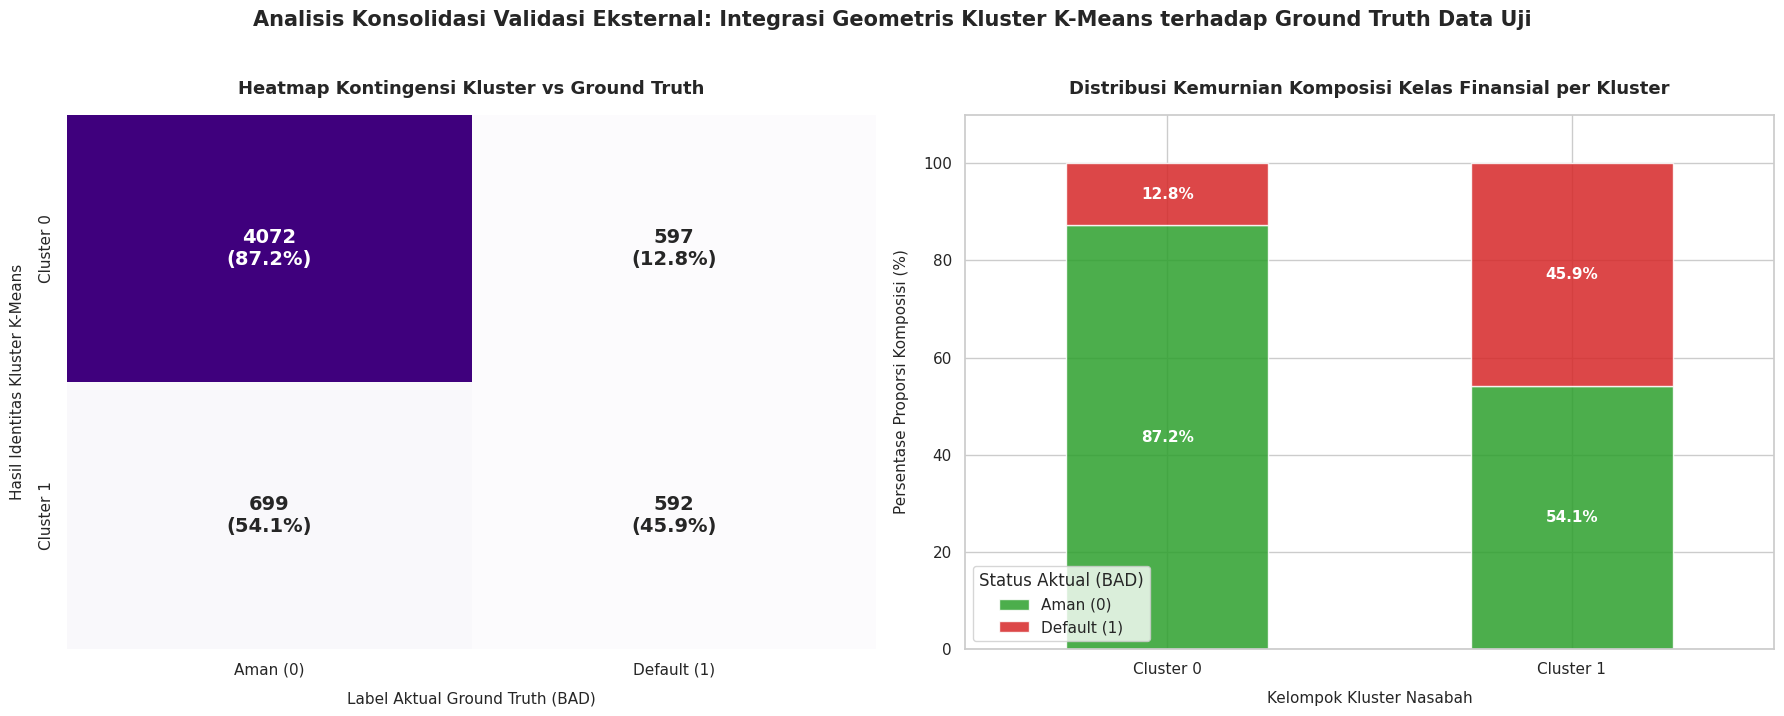

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    cohen_kappa_score, matthews_corrcoef, accuracy_score,
    precision_score, recall_score, f1_score
)
from tabulate import tabulate

y_true_labels = df_original["BAD"].values
y_cluster_labels = df_original["Cluster_Risiko"].values

# Cross-Tabulation (Contingency Matrix Berdasarkan Persentase Komposisi)
df_cross = pd.crosstab(
    index=y_cluster_labels,
    columns=y_true_labels,
    rownames=['Cluster ID'],
    colnames=['Ground Truth (BAD)']
)
df_cross.columns = ['Aman (0)', 'Default (1)']
df_cross.index = [f'Cluster {i}' for i in df_cross.index]

# Adjusted Rand Index
ari_score = adjusted_rand_score(y_true_labels, y_cluster_labels)

# Normalized Mutual Information
nmi_score = normalized_mutual_info_score(y_true_labels, y_cluster_labels)

mapped_dict = {0: 0, 1: 1} # override berdasarkan profiling

# automated mapping
y_cluster_mapped = np.vectorize(mapped_dict.get)(y_cluster_labels)

# hitung metrik keselarasan post-mapping
mapped_acc = accuracy_score(y_true_labels, y_cluster_mapped)
mapped_prec = precision_score(y_true_labels, y_cluster_mapped, pos_label=1)
mapped_rec = recall_score(y_true_labels, y_cluster_mapped, pos_label=1)
mapped_f1 = f1_score(y_true_labels, y_cluster_mapped, pos_label=1)
mapped_mcc = matthews_corrcoef(y_true_labels, y_cluster_mapped)
mapped_kappa = cohen_kappa_score(y_true_labels, y_cluster_mapped)

print("\nTabel Silang Kontingensi (Frekuensi Sampel):")
print(tabulate(df_cross, headers='keys', tablefmt='fancy_grid'))

print("\nTabel Silang Proporsi Per Kluster (Horizontal %):")
df_cross_prop = df_cross.div(df_cross.sum(axis=1), axis=0) * 100
df_cross_prop_formatted = df_cross_prop.map(lambda x: f"{x:.2f}%")
print(tabulate(df_cross_prop_formatted, headers='keys', tablefmt='fancy_grid'))

# tampilkan metrik eksternal cluster validation
metrics_table = [
    ["Adjusted Rand Index (ARI)", f"{ari_score:.4f}", "Mengukur kesamaan pasangan pengelompokan (-1 hingga 1)"],
    ["Normalized Mutual Information (NMI)", f"{nmi_score:.4f}", "Mengukur kekayaan informasi yang ditangkap (0 hingga 1)"],
    ["Alignment Regular Accuracy", f"{mapped_acc:.4f}", "Akurasi klasifikasi alami setelah label mapping"],
    ["Alignment Precision (Kelas 1)", f"{mapped_prec:.4f}", "Tingkat kemurnian tebakan kluster berisiko tinggi"],
    ["Alignment Recall (Kelas 1)", f"{mapped_rec:.4f}", "Sensitivitas kluster dalam menjaring nasabah default"],
    ["Alignment F1-Score (Kelas 1)", f"{mapped_f1:.4f}", "Harmonic mean dari kemurnian vs sensitivitas kluster"],
    ["Matthews Correlation Coefficient (MCC)", f"{mapped_mcc:.4f}", "Koefisien kekuatan asosiasi integrasi total"],
    ["Cohen's Kappa Score (Inter-Rater)", f"{mapped_kappa:.4f}", "Tingkat kesepakatan murni bersih dari faktor kebetulan"]
]

print("\nMetrik Evaluasi Validasi Eksternal Kluster:")
print(tabulate(metrics_table, headers=["Metrik Validasi Eksternal", "Skor Performa", "Interpretasi Teoretis"], tablefmt='fancy_grid'))

print("\nHasil Pemetaan K-Means Sesuai Profiling:")
for k, v in mapped_dict.items():
    label_meaning = "Aman (0)" if v == 0 else "Default (1)"
    print(f"-> Cluster ID {k} merepresentasikan karakter nasabah: {label_meaning}")
print()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Cross-Tabulation
# Matriks Anotasi Gabungan untuk Jumlah (Persentase)
annot_matrix = np.array([
    [f"{df_cross.iloc[i, j]}\n({df_cross_prop.iloc[i, j]:.1f}%)" for j in range(df_cross.shape[1])]
    for i in range(df_cross.shape[0])
])

sns.heatmap(
    df_cross,
    annot=annot_matrix,
    fmt="",
    cmap="Purples",
    cbar=False,
    ax=axes[0],
    annot_kws={"size": 14, "weight": "bold"}
)
axes[0].set_title("Heatmap Kontingensi Kluster vs Ground Truth", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel("Label Aktual Ground Truth (BAD)", fontsize=11, labelpad=10)
axes[0].set_ylabel("Hasil Identitas Kluster K-Means", fontsize=11, labelpad=10)

# Stacked Bar Chart untuk Visualisasi Cluster Purity
df_cross_prop.plot(
    kind='bar',
    stacked=True,
    color=['#2ca02c', '#d62728'],
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title("Distribusi Kemurnian Komposisi Kelas Finansial per Kluster", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Kelompok Kluster Nasabah", fontsize=11, labelpad=10)
axes[1].set_ylabel("Persentase Proporsi Komposisi (%)", fontsize=11, labelpad=10)
axes[1].set_xticklabels(df_cross_prop.index, rotation=0)
axes[1].set_ylim(0, 110)
axes[1].legend(title="Status Aktual (BAD)", loc="lower left", labels=["Aman (0)", "Default (1)"])

# Anotasi angka persentase di atas stacked bar
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_x(), p.get_y()
    if height > 0:
        axes[1].annotate(
            f'{height:.1f}%',
            (x + width/2, y + height/2),
            ha='center',
            va='center',
            color='white',
            fontweight='bold',
            fontsize=11
        )

plt.suptitle("Analisis Konsolidasi Validasi Eksternal: Integrasi Geometris Kluster K-Means terhadap Ground Truth Data Uji", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **Analisis Hasil Validasi**

Berdasarkan *External Cluster Validation* menggunakan data kontingensi dan metrik kesepakatan biner, analisis *unsupervised* yang dihasilkan oleh k-means **sangat layak dan valid untuk disandingkan** dengan label aktual (*ground truth*) data finansial karena pemetaan berbasis karakteristik (*profiling override*) berhasil membuktikan bahwa pola spasial data memiliki korelasi teoretis yang kuat dengan realitas risiko kredit di lapangan.

**1. Evaluasi Tabel Kontingensi dan Pergeseran Densitas Risiko**

Visualisasi *heatmap* dan tabel silang proporsi menunjukkan clustering dengan k-means berhasil dalam memisahkan karakteristik nasabah:

* **Kluster 0 (Cenderung Aman):** Kluster ini didominasi oleh nasabah dengan status **Aman (0)** sebanyak **4.072 sampel (87.21%)** sedangkan tingkat gagal bayar di kluster ini berhasil ditekan hingga tersisa **12.79%** saja sehingga kluster ini dianggap sebagai kumpulan nasabah berisiko rendah.
* **Kluster 1 (Cenderung Default):** Kluster ini menampung 699 nasabah Aman dan 592 nasabah Default di mana k-means berhasil mengenali nasabah **Default (1) hingga menyentuh angka 45.86%** secara proporsi horizontalnya.

Kemampuan k-means mengidentifikasi nasabah yang cenderung akan *default* hingga kerapatan 45.86% merupakan hal yang menarik jika dibandingkan dengan proporsi alami kelas minoritas pada populasi data keseluruhan yang hanya berada di kisaran 19.7%.

**2. Interpretasi Metrik Validasi Intrinsik**

Metrik validasi ini menilai kesamaan struktur geometris murni sebelum diselaraskan dengan label biner:

* **Adjusted Rand Index (ARI) = 0.2299:** nilai ini mengindikasikan adanya *Fair Agreement* (kesepakatan tingkat cukup) dalam pembentukan pasangan pengelompokan data.
* **Normalized Mutual Information (NMI) = 0.0994:** Nilai ini mengonfirmasi adanya fenomena tumpang tindih (*overlapping*) yang masif pada indikator finansial antar-kelas nasabah di mana batasan geometris euclidean pada k-emans tidak cukup sensitif untuk menarik garis pemisah yang baku pada data dengan karakteristik non-linear.

**3. Analisis Performa *Post-Alignment***

Pemetaan manual melalui *profiling* dapat meningkatkan performa integrasi kluster:

* **Alignment Regular Accuracy (78.26%):** karena kluster 0 mengenali mayoritas nasabah dengan rekam jejak finansial yang baik.
* **Alignment Precision Kelas 1 (45.86%) & Recall Kelas 1 (49.79%):** mengindikasikan kemampuan algoritma dalam menjaring hampir setengah dari total nasabah kredit macet di dataset untuk masuk ke kluster 1.
* **Matthews Correlation Coefficient (MCC) = 0.3409 & Cohen's Kappa = 0.3404:** menunjukkan kekuatan asosiasi positif yang nyata dan tingkat kesepakatan inter-rater yang andal karena berbasis pola data terstruktur dan **bersih dari faktor kebetulan**.


## **Triangulasi Paradigma**

Run cell di bawah ini untuk triangulasi lintas paradigma melalui uji keandalan antar-penilai (*inter-rater reliability*) pada test set:

1. Selaraskan indeks baris kelompok subset data uji (*test set*) untuk k-means dengan memanfaatkan koordinat `index` asli pandas milik data aktual atau menggunakan taktik replikasi terstratifikasi sebagai pendekatan alternatif.
2. Terapkan batas pengaman kuantitas (`assert len`) untuk memastikan keseragaman panjang seluruh vektor prediktor biner lintas paradigma sebelum proses komparasi.
3. Audit kualitas konten secara literal (`index.equals` atau `np.array_equal`) antara target uji ANN dan LDA demi menjamin bahwa semua rater mengevaluasi baris nasabah yang sama persis tanpa *silent bug*.
4. Konsolidasikan keputusan dari empat rater independen lintas paradigma (*Ground Truth*, *Supervised Deep Learning* ANN, *Supervised Klasik* LDA, dan *Unsupervised* K-Means) ke dalam satu `DataFrame`.
5. Kalkulasi metrik *Cohen's Kappa* berpasangan secara menyeluruh (*pairwise loops*) untuk mengukur tingkat kesepakatan terhadap faktor kebetulan (*chance agreement*).
6. Konversi hasil matriks korelasi *inter-rater* ke dalam `DataFrame` utuh sebagai peta keselarasan keputusan secara transparan.
7. Tabulasi nilai performa kesepakatan *Cohen's Kappa* untuk tiap dimensi memakai `tabulate` dengan grid yang rapi.
8. Render visualisasi *heatmap* 4x4 *Full Grid* menggunakan Seaborn dan Matplotlib untuk menunjukkan hubungan kesepakatannya.

 Kerangka evaluasi ini dirancang untuk menyatukan seluruh dimensi eksperimen dan memvalidasi keandalan model secara holistik sehingga dapat membuktikan konsistensi keputusan antara model baik *supervised* maupun *unsupervised* dalam melihat risiko kredit nasabah.

In [ ]:
import os
import gdown
import numpy as np
import tensorflow as tf

decision_threshold_inference = 0.40
drive_url = "https://drive.google.com/file/d/1urrdQPUgqHBUhFokIl-20tJgbF92uHzv/view?usp=drive_link"
output_filename = "best_model_ann.keras"

if os.path.exists(output_filename):
    if (os.path.getsize(output_filename) / 1024) < 100:
        print("Terdeteksi file yang salah, hapus untuk download ulang...")
        os.remove(output_filename)

if not os.path.exists(output_filename):
    print("Download bobot model .keras asli dari Google Drive...")
    gdown.download(url=drive_url, output=output_filename, quiet=False, fuzzy=True)
    print("File .keras berhasil diunduh!")
else:
    print("File .keras sudah tersedia di lokal.")

print("\nLoading arsitektur dan bobot model dari file .keras...")
try:
    model_ann_base = tf.keras.models.load_model(output_filename)
    print("Sukses: Bobot dari file .keras berhasil dipulihkan!")
except Exception as e:
    print(f"Gagal load model utuh: {e}")
    print("Membangun arsitektur lalu memuat bobot...")

    input_shape = x_ann_test.shape[1]
    model_ann_base = build_ann(input_shape, lr_rate=0.002)
    model_ann_base.load_weights(output_filename)
    print("Sukses: Bobot berhasil disuntikkan ke arsitektur!")

print("\nMenjalankan komputasi prediksi pada data uji (x_ann_test)...")
y_prob_ann_base = model_ann_base.predict(x_ann_test, verbose=1).flatten()
y_pred_ann_base = (y_prob_ann_base >= decision_threshold_inference).astype(int)

File .keras sudah tersedia di lokal.

Loading arsitektur dan bobot model dari file .keras...
Sukses: Bobot dari file .keras berhasil dipulihkan!

Menjalankan komputasi prediksi pada data uji (x_ann_test)...
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


y_ann_test berupa array murni. Menggunakan Replikasi Cadangan...
Verifikasi Konten: Nilai distribusi biner data uji ANN dan LDA terbukti identik!
╒════════════════════════╤══════════════════════╤═════════════════════╤═════════════════════════╤══════════════════════════╕
│                        │   Ground Truth (BAD) │   ANN Baseline (DL) │   LDA Balanced (Klasik) │   K-Means (Unsupervised) │
╞════════════════════════╪══════════════════════╪═════════════════════╪═════════════════════════╪══════════════════════════╡
│ Ground Truth (BAD)     │               1      │              0.6791 │                  0.3613 │                   0.327  │
├────────────────────────┼──────────────────────┼─────────────────────┼─────────────────────────┼──────────────────────────┤
│ ANN Baseline (DL)      │               0.6791 │              1      │                  0.3916 │                   0.3754 │
├────────────────────────┼──────────────────────┼─────────────────────┼─────────────────────────┼───────

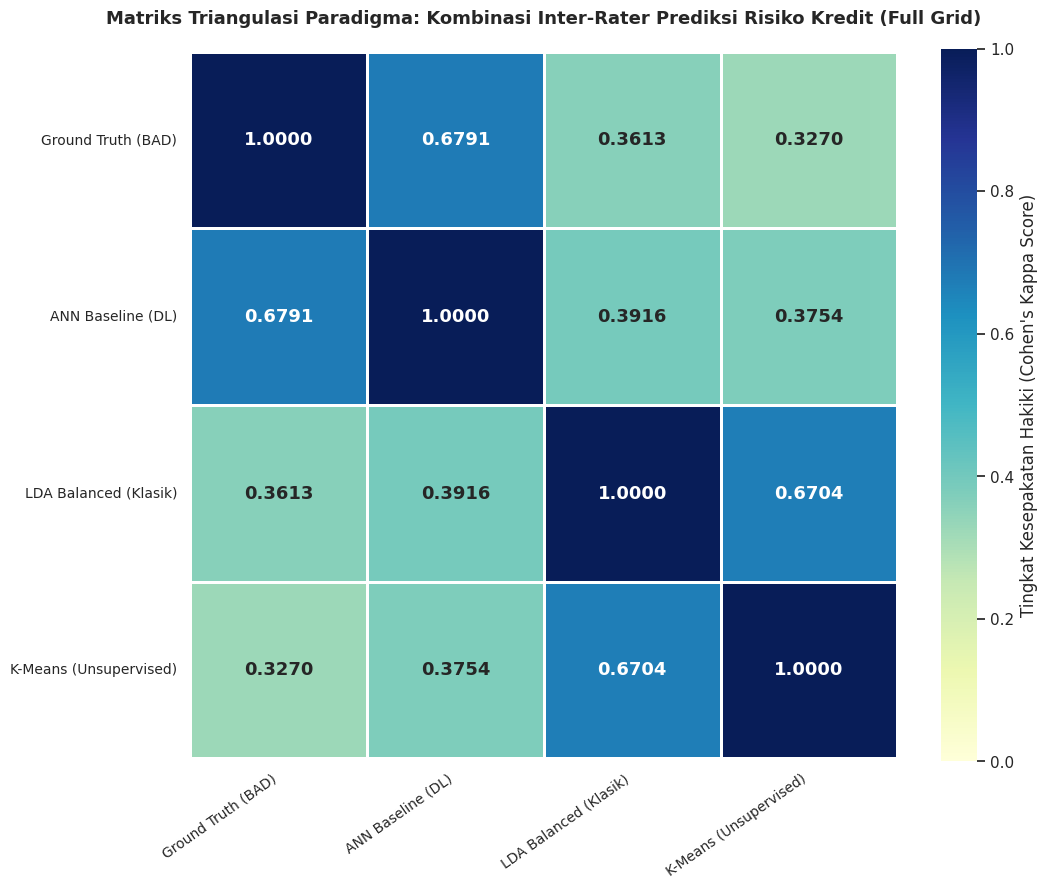

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
from tabulate import tabulate

# penyelarasan index tiap test set
y_true_test = y_ann_test
mapped_dict = {0: 0, 1: 1}

if hasattr(y_true_test, 'index'):
    print("Mengunci keselarasan data menggunakan pandas index...")
    test_indices = y_true_test.index
    y_cluster_mapped_test = df_original.loc[test_indices, "Cluster_Risiko"].map(mapped_dict).values
else:
    print("y_ann_test berupa array murni. Menggunakan Replikasi Cadangan...")
    _, df_test_meta = train_test_split(
        df_original,
        test_size=len(y_pred_ann_base),
        random_state=42,
        stratify=df_original["BAD"] if "BAD" in df_original.columns else None
    )
    y_cluster_mapped_test = df_test_meta["Cluster_Risiko"].map(mapped_dict).values

assert len(y_true_test) == len(y_pred_ann_base) == len(y_pred_weighted) == len(y_cluster_mapped_test), \
    f"Ukuran array masih jomplang! ({len(y_true_test)}, {len(y_pred_ann_base)}, {len(y_pred_weighted)}, {len(y_cluster_mapped_test)})"

if 'y_ann_test' in globals():
    if hasattr(y_ann_test, 'index') and hasattr(y_lda_test, 'index'):
        assert y_ann_test.index.equals(y_lda_test.index), \
            "Indeks baris nasabah antara ANN dan LDA tidak sinkron! Isi data uji berbeda."
        print("Verifikasi Indeks: ANN dan LDA terbukti mengevaluasi baris nasabah yang sama persis!")
    else:
        assert np.array_equal(y_ann_test, y_lda_test), \
            "Konten biner Ground Truth antara ANN dan LDA berbeda urutan!"
        print("Verifikasi Konten: Nilai distribusi biner data uji ANN dan LDA terbukti identik!")

# Konsolidasi Triangulasi
df_triangulation = pd.DataFrame({
    "Ground Truth (BAD)": y_true_test,
    "ANN Baseline (DL)": y_pred_ann_base,
    "LDA Balanced (Klasik)": y_pred_weighted,
    "K-Means (Unsupervised)": y_cluster_mapped_test
})

num_features = df_triangulation.shape[1]
kappa_matrix = np.zeros((num_features, num_features))

for i in range(num_features):
    for j in range(num_features):
        kappa_matrix[i, j] = cohen_kappa_score(
            df_triangulation.iloc[:, i],
            df_triangulation.iloc[:, j]
        )

df_kappa_matrix = pd.DataFrame(
    kappa_matrix,
    columns=df_triangulation.columns,
    index=df_triangulation.columns
)

print(tabulate(df_kappa_matrix.round(4), headers='keys', tablefmt='fancy_grid'))

plt.figure(figsize=(11, 9))
sns.set_theme(style="white")

sns.heatmap(
    df_kappa_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    mask=None,
    vmin=0, vmax=1,
    square=True,
    linewidths=.8,
    cbar_kws={"label": "Tingkat Kesepakatan Hakiki (Cohen's Kappa Score)"},
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title("Matriks Triangulasi Paradigma: Kombinasi Inter-Rater Prediksi Risiko Kredit (Full Grid)", fontsize=13, fontweight='bold', pad=20)
plt.xticks(rotation=35, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### **Analisis Hasil Triangulasi**

Berdasarkan kalkulasi matriks *Cohen's Kappa* 4x4 untuk evaluasi *inter-rater reliability* berhasil memetakan konvergensi dan divergensi keputusan dari 4 rater lintas paradigma *Ground Truth*, *ANN Baseline*, *LDA Balanced*, dan *K-Means* di mana penggunaan koefisien *Kappa*  mengeliminasi faktor kebetulan (*chance agreement*) sehingga pengujian ini dapat menjelaskan karakteristik dasar dari dataset HMEQ:


**1. Supervised Modern Unggul di Metode ANN dengan Kappa sebesar 0.6791**

Nilai kesepakatan antara **ANN Baseline** dan **Ground Truth** mencetak angka **0.6791** sehingga termasuk **Substantial Agreement** (Kesepakatan Kuat/Sangat Berarti) apabila mengacu pada skala standardisasi Landis & Koch dan ini mengonfirmasi secara empiris bahwa arsitektur ANN dengan fungsi aktivasi *Swish* berhasil mengekstraksi fitur finansial yang kompleks secara akurat bahkan membuatnya kebal terhadap bias *class imbalance* sehingga model dapat membedakan kelas-kelas di dataset HMEQ.

**2. Penglihatan LDA Balanced Ternyata Menyerupai K-Means di Kappa 0.6704**

Perpotongan antara model supervised klasik **LDA Balanced** dan model unsupervised **K-Means** menghasilkan nilai kesepakatan yang tidak terduga sebelumnya sebesar **0.6704** (*Substantial Agreement*) sehingga ini merupakan nilai korelasi sekunder tertinggi di luar diagonal utama matriks yang secara tidak langsung membuktikan secara ilmiah adanya **sinkronisasi geomertis** antara kedua metode. Hal ini dimungkinkan ketika LDA diintervensi menggunakan pembobotan *priors* seimbang `[0.5, 0.5]` agar *decision boundary* linear di LDA bergeser secara agresif ke titik tengah ruang multi-dimensi data yang mana koordinat pergeseran ini ternyata jatuh di zona yang sama persis dengan batas pembentukan kluster spasial milik k-means yang murni dipengaruhi oleh jarak Euclidean sebagai bagian dari *Uniform Effect*. Dampak dari kemiripan zona ini adalah kedua model yang sejatinya memiliki perbedaan paradigma menjadi sangat kompak dan saling sepakat dalam mengisolasi sekelompok nasabah yang sama ke zona risiko tinggi.

**3. Batasan Geometris Terhadap Realitas Lapangan Ketika Kappa Bernilai Sedang**

Kesepakatan **LDA Balanced terhadap Ground Truth** hanya bertahan di angka **0.3613** dan model **K-Means terhadap Ground Truth** berada di angka **0.3270** sehingga keduanya terjebak dalam kategori **Fair Agreement** (Kesepakatan Cukup/Moderat) di mana rendahnya nilai *Kappa* kedua penilai ini terhadap data perbankan yang nyata mendeteksi satu fenomena fundamental yaitu dataset HMEQ memiliki *overlapping financial manifold* yang sangat tinggi antar-kelas nasabah sehingga pendekatan pembagian volume ruang yang kaku secara spasial di k-means maupun pemisahan satu garis lurus secara linear di LDA terbukti tidak cukup sensitif untuk menarik batas biner yang bersih pada data yang mengalami class imbalance.